In [141]:
import anndata as ad
import numpy as np
import pandas as pd
import SDP_miRNA.dataset
import SDP_miRNA.optimization
import SDP_miRNA.optimization_MOSEK
import SDP_miRNA.correlation
import SDP_miRNA.simulation
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from itertools import combinations

In [6]:
rng = np.random.default_rng(392)

# (1) Simulated data: miRNA - {mRNA targets}

## Simulate data

In [334]:
def correlation_point(path):

    _, S = path.shape

    corr = np.corrcoef(path.T)[np.triu_indices(S, 1)]

    corr_miRNA = corr[:S - 1]
    corr_mRNA = corr[S - 1:]

    return corr_miRNA, corr_mRNA

In [335]:
targets = 3
k_tx = 2
k_deg = 1
k_reg = 5

stoch_inp = np.zeros((2 + targets * 3, 1 + targets))
stoch_out = np.zeros((2 + targets * 3, 1 + targets))
rates = np.ones(2 + 3 * targets)

# miRNA tx and deg reactions
stoch_out[0, 0] = 1
rates[0] = k_tx
stoch_inp[1, 0] = 1
rates[1] = k_deg

for m in range(targets):

    r = 2 + 3 * m
    s = 1 + m

    # mRNA tx and deg reactions
    stoch_out[r, s] = 1
    rates[r] = k_tx
    stoch_inp[r + 1, s] = 1
    rates[r + 1] = k_deg

    # miRNA - mRNA interaction
    stoch_inp[r + 2, 0] = 1
    stoch_inp[r + 2, s] = 1
    stoch_out[r + 2, 0] = 1
    rates[r + 2] = k_reg

In [336]:
initial = None
tmax = 10100
tmin = 100
tint = 10
n = 1000

# run gillespie
path, path_times = SDP_miRNA.simulation.gillespie(stoch_inp, stoch_out, rates, initial, tmax)

In [337]:
# take samples at uniform time points
sample = SDP_miRNA.simulation.uniform_time_samples(path, path_times, tmin=tmin, tmax=tmax, tint=tint, n=n)

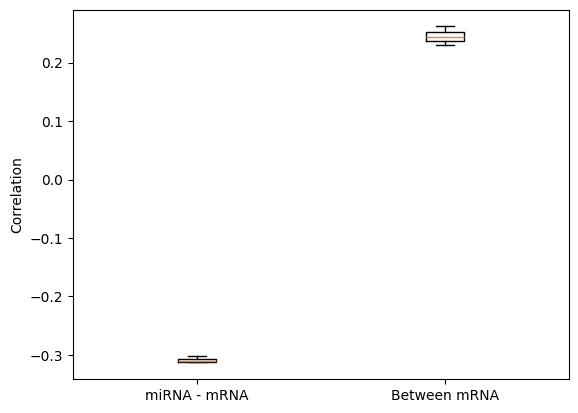

In [338]:
# compute correlations
corr_miRNA, corr_mRNA = correlation_point(sample)

# display
fig, axs = plt.subplots()
axs.boxplot([corr_miRNA, corr_mRNA], positions=[0, 1])
axs.set_xticklabels(["miRNA - mRNA", "Between mRNA"])
axs.set_ylabel("Correlation")
plt.show()

In [83]:
# simulate independent mRNA
mRNA_indep = rng.poisson(k_tx / k_deg, size=n).reshape(-1, 1)

# construct full data
RNA_data_original = np.hstack([sample, mRNA_indep]).astype(np.int64)

In [96]:
# capture
mean_capture = 0.5
capture_shape = 30
capture_scale = (capture_shape / mean_capture) * (1 - mean_capture)

# sample capture
beta = rng.beta(capture_shape, capture_scale, size=n)

# downsample
RNA_data = rng.binomial(RNA_data_original, beta[:, None])

## Display correlations

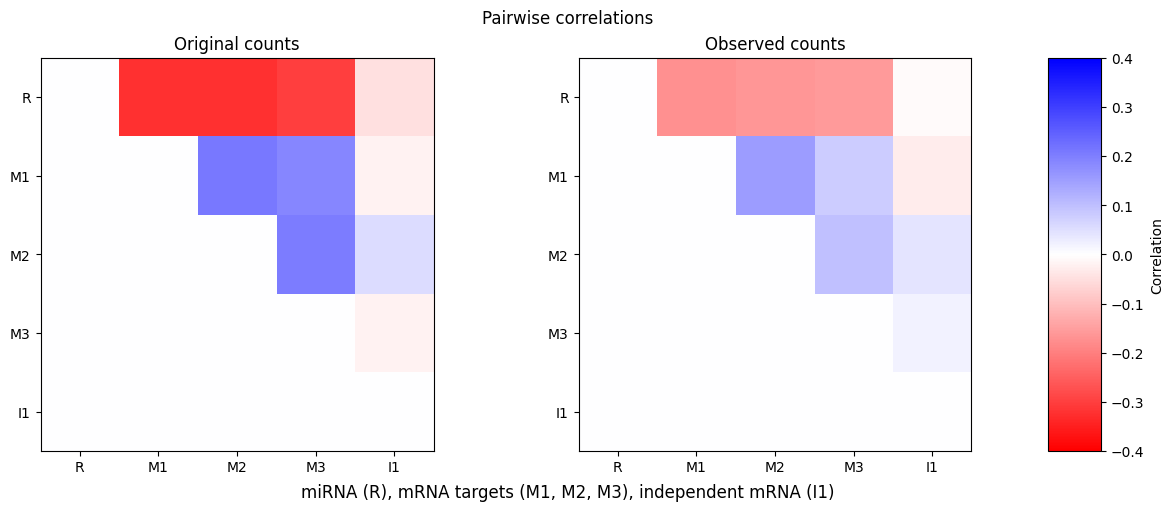

In [98]:
# compute original and observed data point correlations
correlation_matrix_original = np.corrcoef(RNA_data_original.T)
correlation_matrix_observed = np.corrcoef(RNA_data.T)

# remove redundant values
correlation_matrix_original[np.tril_indices(correlation_matrix_original.shape[0], k=0)] = 0
correlation_matrix_observed[np.tril_indices(correlation_matrix_observed.shape[0], k=0)] = 0

# display
RNA_labels = ["R", "M1", "M2", "M3", "I1"]
cmap = LinearSegmentedColormap.from_list('a', ['red', 'white', 'blue'])
fig, axs = plt.subplots(1, 3, figsize=(12, 5), gridspec_kw={'width_ratios': [1, 1, 0.1]}, constrained_layout=True)
im = axs[0].imshow(correlation_matrix_original, cmap=cmap, vmin=-0.4, vmax=0.4)
im = axs[1].imshow(correlation_matrix_observed, cmap=cmap, vmin=-0.4, vmax=0.4)
axs[0].set_title("Original counts")
axs[0].set_xticks(range(5))
axs[0].set_xticklabels(RNA_labels)
axs[0].set_yticks(range(5))
axs[0].set_yticklabels(RNA_labels)
axs[1].set_title("Observed counts")
axs[1].set_xticks(range(5))
axs[1].set_xticklabels(RNA_labels)
axs[1].set_yticks(range(5))
axs[1].set_yticklabels(RNA_labels)
fig.suptitle("Pairwise correlations")
fig.supxlabel("miRNA (R), mRNA targets (M1, M2, M3), independent mRNA (I1)")
plt.colorbar(im, cax=axs[2], label="Correlation")
plt.show()

## Optimize

In [270]:
# construct dataset
data_SDP = SDP_miRNA.dataset.Dataset()

# duplicate full data (miRNA + mRNA) for easy indexing
data_SDP.construct_dataset_array(
    RNA_data,
    RNA_data,
    beta
)

# total species
D = RNA_data.shape[1]

In [271]:
# store results
results = np.empty((D, D), dtype=object)
for i in range(D):
    for j in range(i + 1, D):
        results[i, j] = {S: [] for S in range(2, D + 1)}

In [272]:
# settings
d = 3

# for each number of species
for S in range(2, D + 1):

    # get all unique species selections
    combs = list(combinations(range(D), r=S))

    # construct gene queries (index all from sparse_A)
    gene_queries = [
        [list(idxs), []] for idxs in combs
    ]

    # update dataset
    data_SDP.gene_queries = gene_queries
    data_SDP.total_gene_queries = len(gene_queries)

    # bootstrap
    data_SDP.bootstrap(d=d)

    # Model Free Interacting test
    MF_int = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(data_SDP, d=d)
    MF_int.analyse_dataset()

    # compute pairwise correlations from H&R samples
    for sx in range(S):
        for sy in range(sx + 1, S):
            _, HAR_interval = MF_int.compute_dataset_correlation(Sx=sx, Sy=sy)
            HAR_midpoint = (HAR_interval[:, 0] + HAR_interval[:, 1]) / 2

            # store point & intervals
            for i, query in enumerate(gene_queries):
                results[query[0][sx], query[0][sy]][S].append(np.array([HAR_midpoint[i], HAR_interval[i, 0], HAR_interval[i, 1]]))

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 10.01it/s]


In [273]:
# pairwise independence test & analytic correlation

# get indices (need to use sparse_A & sparse_B or else correlation complains)
Is, Js = np.triu_indices(D, k=1)
gene_queries = [
    [[int(i)], [int(j)]] for i, j in zip(Is, Js)
]

# update dataset
data_SDP.gene_queries = gene_queries
data_SDP.total_gene_queries = len(gene_queries)

# bootstrap
data_SDP.bootstrap(d=d)

# Model Free Independence test
MF_ind = SDP_miRNA.optimization.ModelFreeOptimization(data_SDP, d=d)
MF_ind.analyse_dataset()

# store status
for i, query in enumerate(gene_queries):
    status = (MF_ind.result_dict[i]['status'] == "OPTIMAL")
    results[query[0][0], query[1][0]]['independent'] = status

# analytic correlation
OB, AL = SDP_miRNA.correlation.compute_correlations(data_SDP)

# store point & intervals
for i, query in enumerate(gene_queries):
    results[query[0][0], query[1][0]]['OB'] = OB[i, :]
    results[query[0][0], query[1][0]]['AL'] = AL[i, :]

100%|██████████| 1/1 [00:00<00:00, 29.69it/s]


## Display results

### Single pair

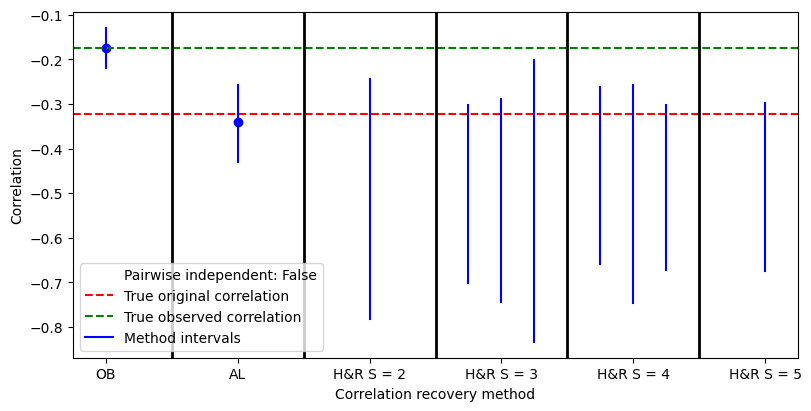

In [274]:
i, j = 0, 1

fig, axs = plt.subplots(1, 1, squeeze=False, figsize=(8, 4), constrained_layout=True)

# independence test
axs[0, 0].plot([], [], label=f"Pairwise independent: {results[i, j]['independent']}", color="white")

# true correlations
axs[0, 0].axhline(correlation_matrix_original[i, j], linestyle="--", color="red", label="True original correlation")
axs[0, 0].axhline(correlation_matrix_observed[i, j], linestyle="--", color="green", label="True observed correlation")

#OB
axs[0, 0].plot([0.5]*2, results[i, j]['OB'][1:], color="blue", label="Method intervals")
axs[0, 0].scatter([0.5], results[i, j]['OB'][0], color="blue")

# AL
axs[0, 0].plot([1.5]*2, results[i, j]['AL'][1:], color="blue")
axs[0, 0].scatter([1.5], results[i, j]['AL'][0], color="blue")

# H&R intervals
for S in range(2, D + 1):
    intervals = results[i, j][S]
    K = len(intervals) + 1
    for k, interval in enumerate(intervals):
        axs[0, 0].plot([S + ((k + 1) / K)]*2, interval[1:], color="blue")
        #axs[0, 0].scatter([S + ((k + 1) / K)], interval[0], color="blue")

# dividers
for k in range(1, D + 1):
    axs[0, 0].axvline(k, color="black", lw=2)

# labels
axs[0, 0].set_ylabel("Correlation")
axs[0, 0].set_xticks([k + 0.5 for k in range(D + 1)])
axs[0, 0].set_xticklabels(["OB", "AL"] + [f"H&R S = {S}" for S in range(2, D + 1)])
axs[0, 0].set_xlabel("Correlation recovery method")
axs[0, 0].legend()

### Gridplot

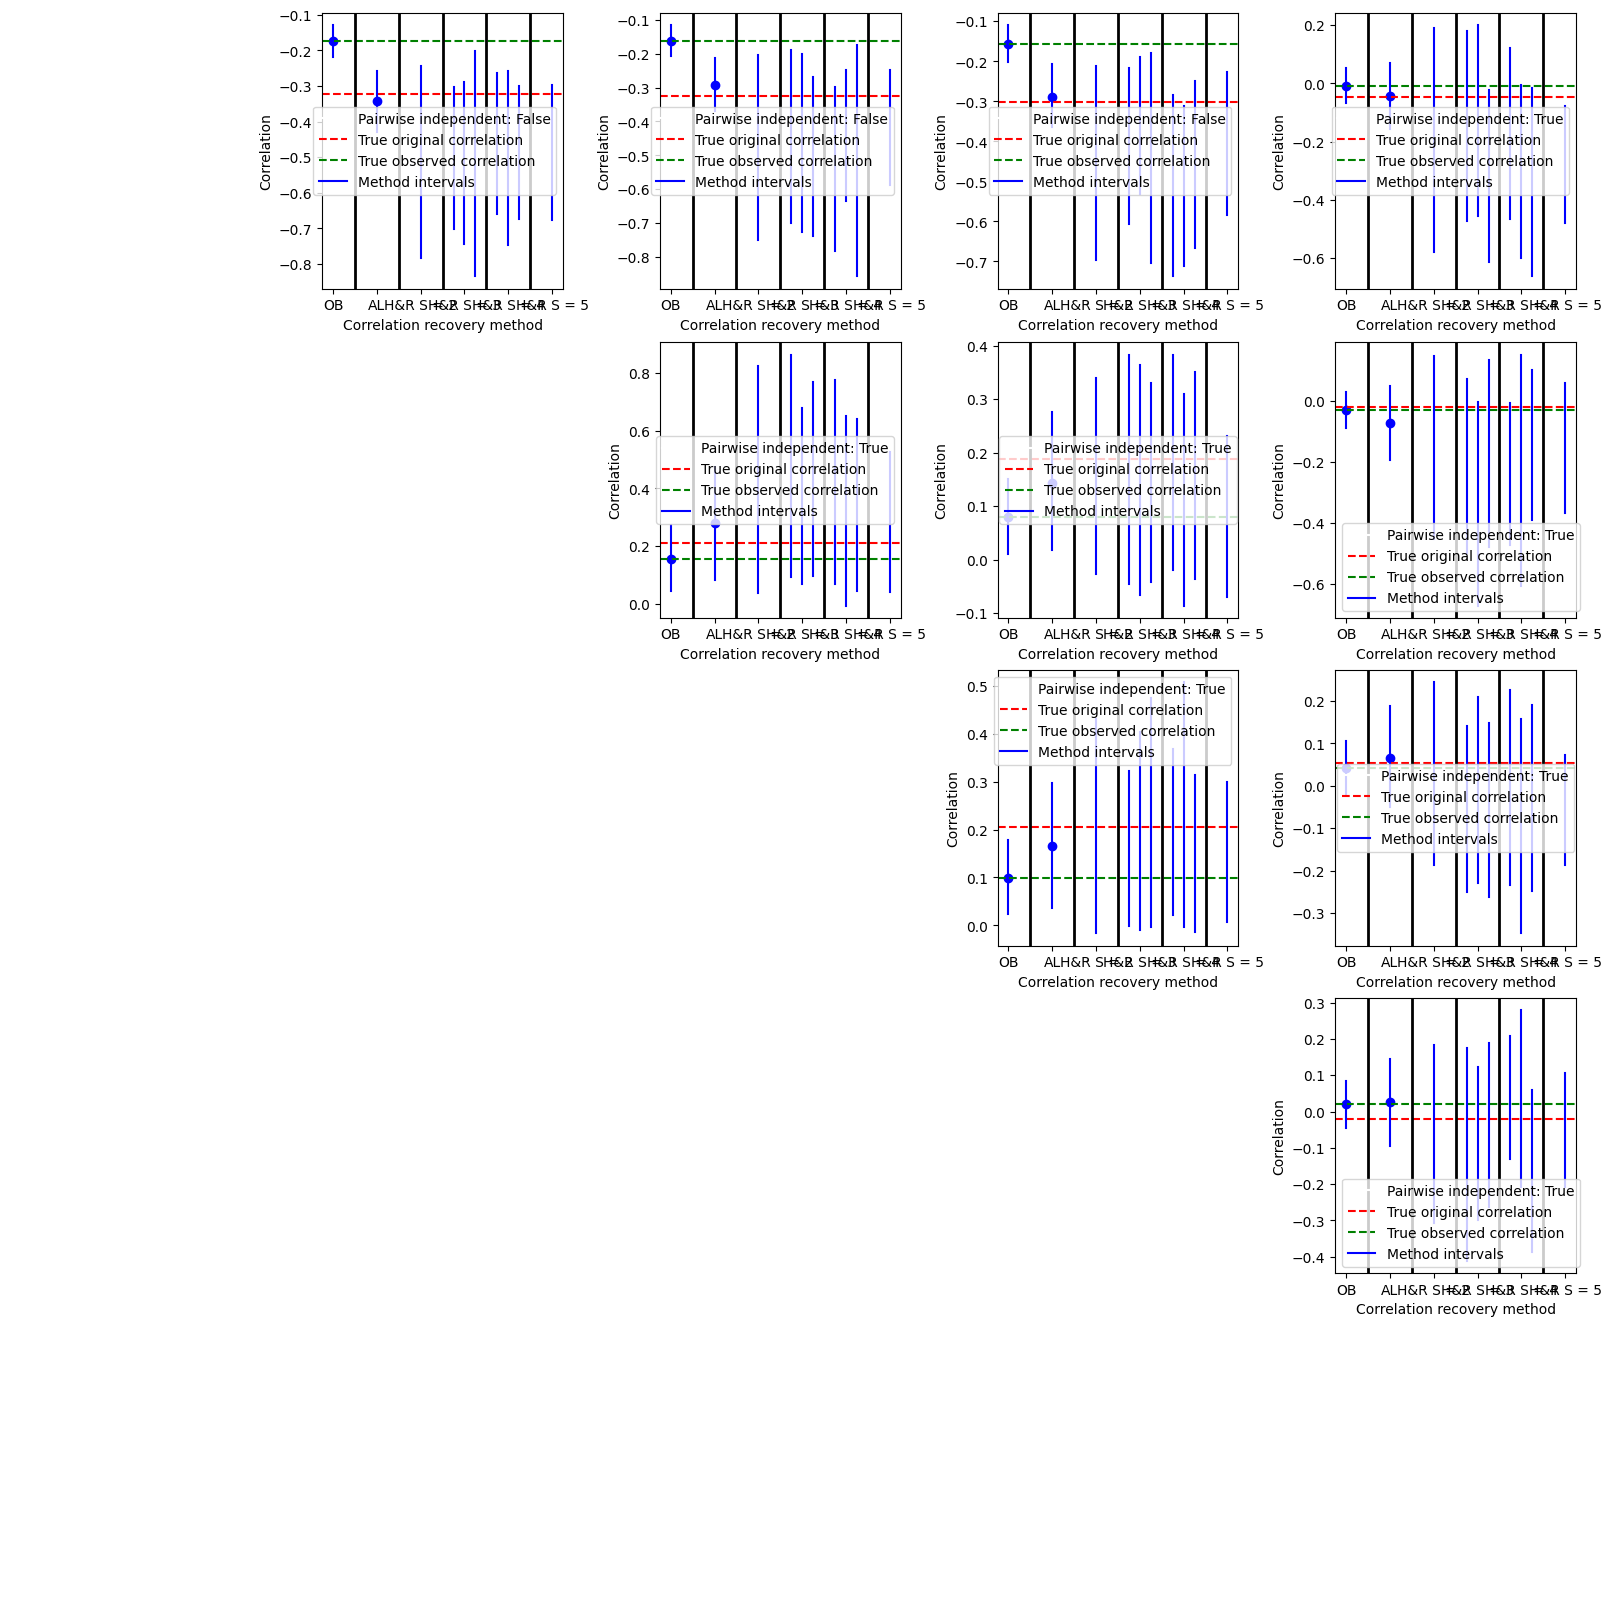

In [275]:
fig, axs = plt.subplots(D, D, squeeze=False, figsize=(16, 16), constrained_layout=True)

for i in range(D):
    for j in range(D):

        if j <= i:
            axs[i, j].axis('off')
            continue

        # independence test
        axs[i, j].plot([], [], label=f"Pairwise independent: {results[i, j]['independent']}", color="white")

        # true correlations
        axs[i, j].axhline(correlation_matrix_original[i, j], linestyle="--", color="red", label="True original correlation")
        axs[i, j].axhline(correlation_matrix_observed[i, j], linestyle="--", color="green", label="True observed correlation")

        #OB
        axs[i, j].plot([0.5]*2, results[i, j]['OB'][1:], color="blue", label="Method intervals")
        axs[i, j].scatter([0.5], results[i, j]['OB'][0], color="blue")

        # AL
        axs[i, j].plot([1.5]*2, results[i, j]['AL'][1:], color="blue")
        axs[i, j].scatter([1.5], results[i, j]['AL'][0], color="blue")

        # H&R intervals
        for S in range(2, D + 1):
            intervals = results[i, j][S]
            K = len(intervals) + 1
            for k, interval in enumerate(intervals):
                axs[i, j].plot([S + ((k + 1) / K)]*2, interval[1:], color="blue")
                #axs[i, j].scatter([S + ((k + 1) / K)], interval[0], color="blue")

        # dividers
        for k in range(1, D + 1):
            axs[i, j].axvline(k, color="black", lw=2)

        # labels
        axs[i, j].set_ylabel("Correlation")
        axs[i, j].set_xticks([k + 0.5 for k in range(D + 1)])
        axs[i, j].set_xticklabels(["OB", "AL"] + [f"H&R S = {S}" for S in range(2, D + 1)])
        axs[i, j].set_xlabel("Correlation recovery method")
        axs[i, j].legend()

### Stacked plot

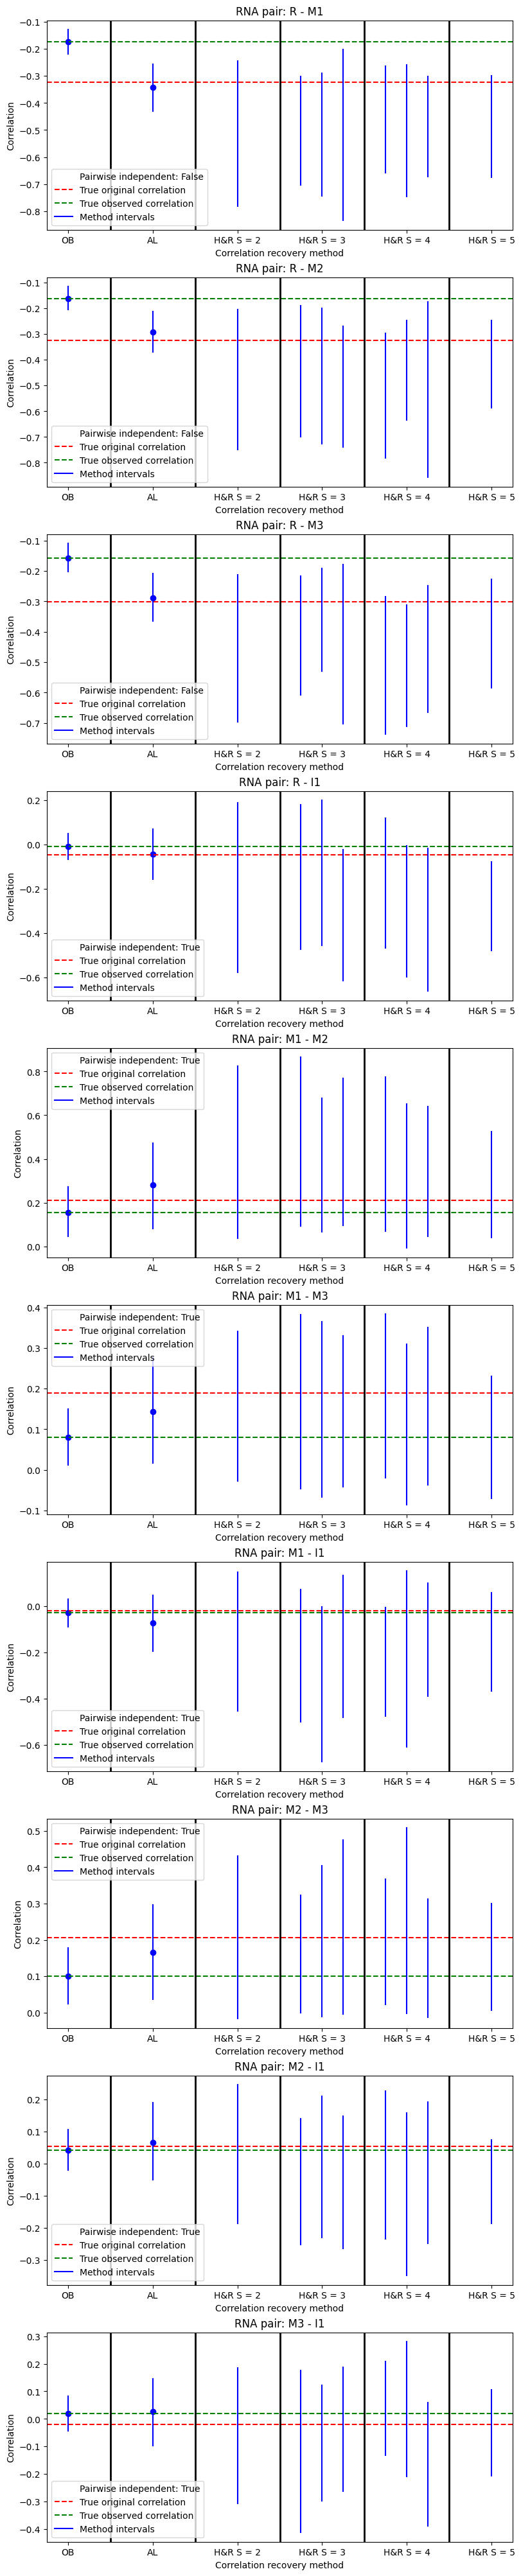

In [276]:
M = D * (D - 1) // 2

fig, axs = plt.subplots(M, 1, squeeze=False, figsize=(8, 4 * M), constrained_layout=True)

m = 0
for i in range(D):
    for j in range(i + 1, D):

        # independence test
        axs[m, 0].plot([], [], label=f"Pairwise independent: {results[i, j]['independent']}", color="white")

        # true correlations
        axs[m, 0].axhline(correlation_matrix_original[i, j], linestyle="--", color="red", label="True original correlation")
        axs[m, 0].axhline(correlation_matrix_observed[i, j], linestyle="--", color="green", label="True observed correlation")

        #OB
        axs[m, 0].plot([0.5]*2, results[i, j]['OB'][1:], color="blue", label="Method intervals")
        axs[m, 0].scatter([0.5], results[i, j]['OB'][0], color="blue")

        # AL
        axs[m, 0].plot([1.5]*2, results[i, j]['AL'][1:], color="blue")
        axs[m, 0].scatter([1.5], results[i, j]['AL'][0], color="blue")

        # H&R intervals
        for S in range(2, D + 1):
            intervals = results[i, j][S]
            K = len(intervals) + 1
            for k, interval in enumerate(intervals):
                axs[m, 0].plot([S + ((k + 1) / K)]*2, interval[1:], color="blue")
                #axs[m, 0].scatter([S + ((k + 1) / K)], interval[0], color="blue")

        # dividers
        for k in range(1, D + 1):
            axs[m, 0].axvline(k, color="black", lw=2)

        # labels
        axs[m, 0].set_ylabel("Correlation")
        axs[m, 0].set_xticks([k + 0.5 for k in range(D + 1)])
        axs[m, 0].set_xticklabels(["OB", "AL"] + [f"H&R S = {S}" for S in range(2, D + 1)])
        axs[m, 0].set_xlabel("Correlation recovery method")
        axs[m, 0].legend()

        # title
        axs[m, 0].set_title(f"RNA pair: {RNA_labels[i]} - {RNA_labels[j]}")

        m += 1

### Coverage statistics

In [277]:
coverage_list = []
for S in range(2, D + 1):
    coverage = []
    for i in range(D):
        for j in range(i + 1, D):
            for interval in results[i, j][S]:
                if interval[1] <= correlation_matrix_original[i, j] and interval[2] >= correlation_matrix_original[i, j]:
                    coverage.append(1)
                else:
                    coverage.append(0)                  
    coverage_list.append(float(np.mean(coverage)))

In [278]:
coverage_list

[1.0, 1.0, 0.9666666666666667, 0.9]

### Width statistics

In [279]:
widths_list = []
for S in range(2, D + 1):
    widths = []
    for i in range(D):
        for j in range(i + 1, D):
            for interval in results[i, j][S]:
                widths.append(interval[2] - interval[1])
    widths_list.append(widths)

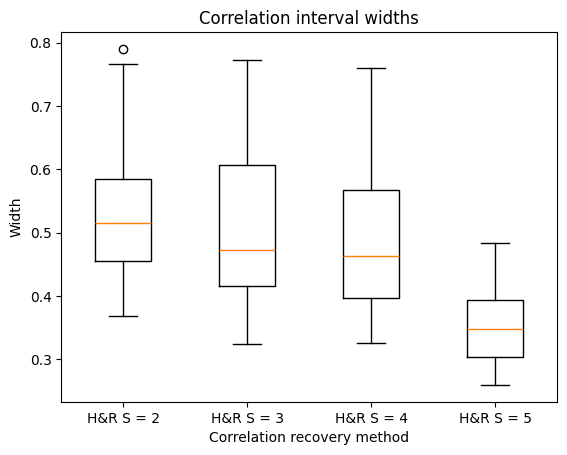

In [280]:
fig, axs = plt.subplots()
axs.boxplot(widths_list);
axs.set_xticklabels([f"H&R S = {S}" for S in range(2, D + 1)])
axs.set_ylabel("Width")
axs.set_xlabel("Correlation recovery method")
axs.set_title("Correlation interval widths")
plt.show()

## Repeat with more H&R samples

In [237]:
# construct dataset
data_SDP = SDP_miRNA.dataset.Dataset()

# duplicate full data (miRNA + mRNA) for easy indexing
data_SDP.construct_dataset_array(
    RNA_data,
    RNA_data,
    beta
)

# total species
D = RNA_data.shape[1]

In [238]:
# store results
results = np.empty((D, D), dtype=object)
for i in range(D):
    for j in range(i + 1, D):
        results[i, j] = {S: [] for S in range(2, D + 1)}

In [239]:
# settings
d = 3

# for each number of species
for S in range(2, D + 1):

    # get all unique species selections
    combs = list(combinations(range(D), r=S))

    # construct gene queries (index all from sparse_A)
    gene_queries = [
        [list(idxs), []] for idxs in combs
    ]

    # update dataset
    data_SDP.gene_queries = gene_queries
    data_SDP.total_gene_queries = len(gene_queries)

    # bootstrap
    data_SDP.bootstrap(d=d)

    # Model Free Interacting test
    MF_int = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(data_SDP, d=d, N=10000)
    MF_int.analyse_dataset()

    # compute pairwise correlations from H&R samples
    for sx in range(S):
        for sy in range(sx + 1, S):
            _, HAR_interval = MF_int.compute_dataset_correlation(Sx=sx, Sy=sy)
            HAR_midpoint = (HAR_interval[:, 0] + HAR_interval[:, 1]) / 2

            # store point & intervals
            for i, query in enumerate(gene_queries):
                results[query[0][sx], query[0][sy]][S].append(np.array([HAR_midpoint[i], HAR_interval[i, 0], HAR_interval[i, 1]]))

100%|██████████| 1/1 [00:00<00:00, 14.76it/s]


100%|██████████| 1/1 [00:01<00:00,  1.05s/it]


In [240]:
# pairwise independence test & analytic correlation

# get indices (need to use sparse_A & sparse_B or else correlation complains)
Is, Js = np.triu_indices(D, k=1)
gene_queries = [
    [[int(i)], [int(j)]] for i, j in zip(Is, Js)
]

# update dataset
data_SDP.gene_queries = gene_queries
data_SDP.total_gene_queries = len(gene_queries)

# bootstrap
data_SDP.bootstrap(d=d)

# Model Free Independence test
MF_ind = SDP_miRNA.optimization.ModelFreeOptimization(data_SDP, d=d)
MF_ind.analyse_dataset()

# store status
for i, query in enumerate(gene_queries):
    status = (MF_ind.result_dict[i]['status'] == "OPTIMAL")
    results[query[0][0], query[1][0]]['independent'] = status

# analytic correlation
OB, AL = SDP_miRNA.correlation.compute_correlations(data_SDP)

# store point & intervals
for i, query in enumerate(gene_queries):
    results[query[0][0], query[1][0]]['OB'] = OB[i, :]
    results[query[0][0], query[1][0]]['AL'] = AL[i, :]

100%|██████████| 1/1 [00:00<00:00, 36.60it/s]


### Single pair

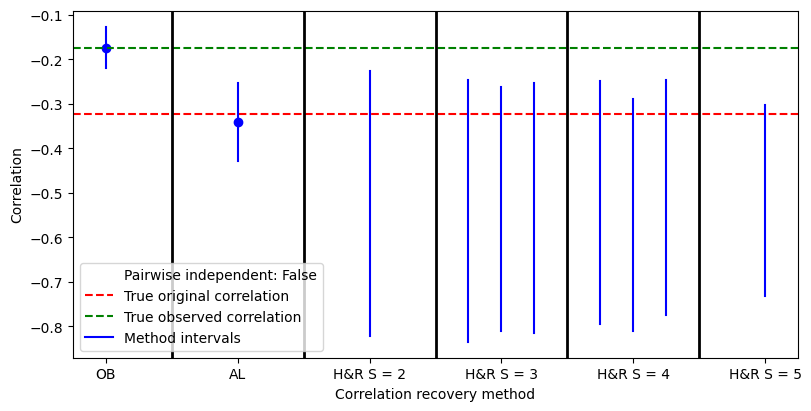

In [241]:
i, j = 0, 1

fig, axs = plt.subplots(1, 1, squeeze=False, figsize=(8, 4), constrained_layout=True)

# independence test
axs[0, 0].plot([], [], label=f"Pairwise independent: {results[i, j]['independent']}", color="white")

# true correlations
axs[0, 0].axhline(correlation_matrix_original[i, j], linestyle="--", color="red", label="True original correlation")
axs[0, 0].axhline(correlation_matrix_observed[i, j], linestyle="--", color="green", label="True observed correlation")

#OB
axs[0, 0].plot([0.5]*2, results[i, j]['OB'][1:], color="blue", label="Method intervals")
axs[0, 0].scatter([0.5], results[i, j]['OB'][0], color="blue")

# AL
axs[0, 0].plot([1.5]*2, results[i, j]['AL'][1:], color="blue")
axs[0, 0].scatter([1.5], results[i, j]['AL'][0], color="blue")

# H&R intervals
for S in range(2, D + 1):
    intervals = results[i, j][S]
    K = len(intervals) + 1
    for k, interval in enumerate(intervals):
        axs[0, 0].plot([S + ((k + 1) / K)]*2, interval[1:], color="blue")
        #axs[0, 0].scatter([S + ((k + 1) / K)], interval[0], color="blue")

# dividers
for k in range(1, D + 1):
    axs[0, 0].axvline(k, color="black", lw=2)

# labels
axs[0, 0].set_ylabel("Correlation")
axs[0, 0].set_xticks([k + 0.5 for k in range(D + 1)])
axs[0, 0].set_xticklabels(["OB", "AL"] + [f"H&R S = {S}" for S in range(2, D + 1)])
axs[0, 0].set_xlabel("Correlation recovery method")
axs[0, 0].legend()

### Gridplot

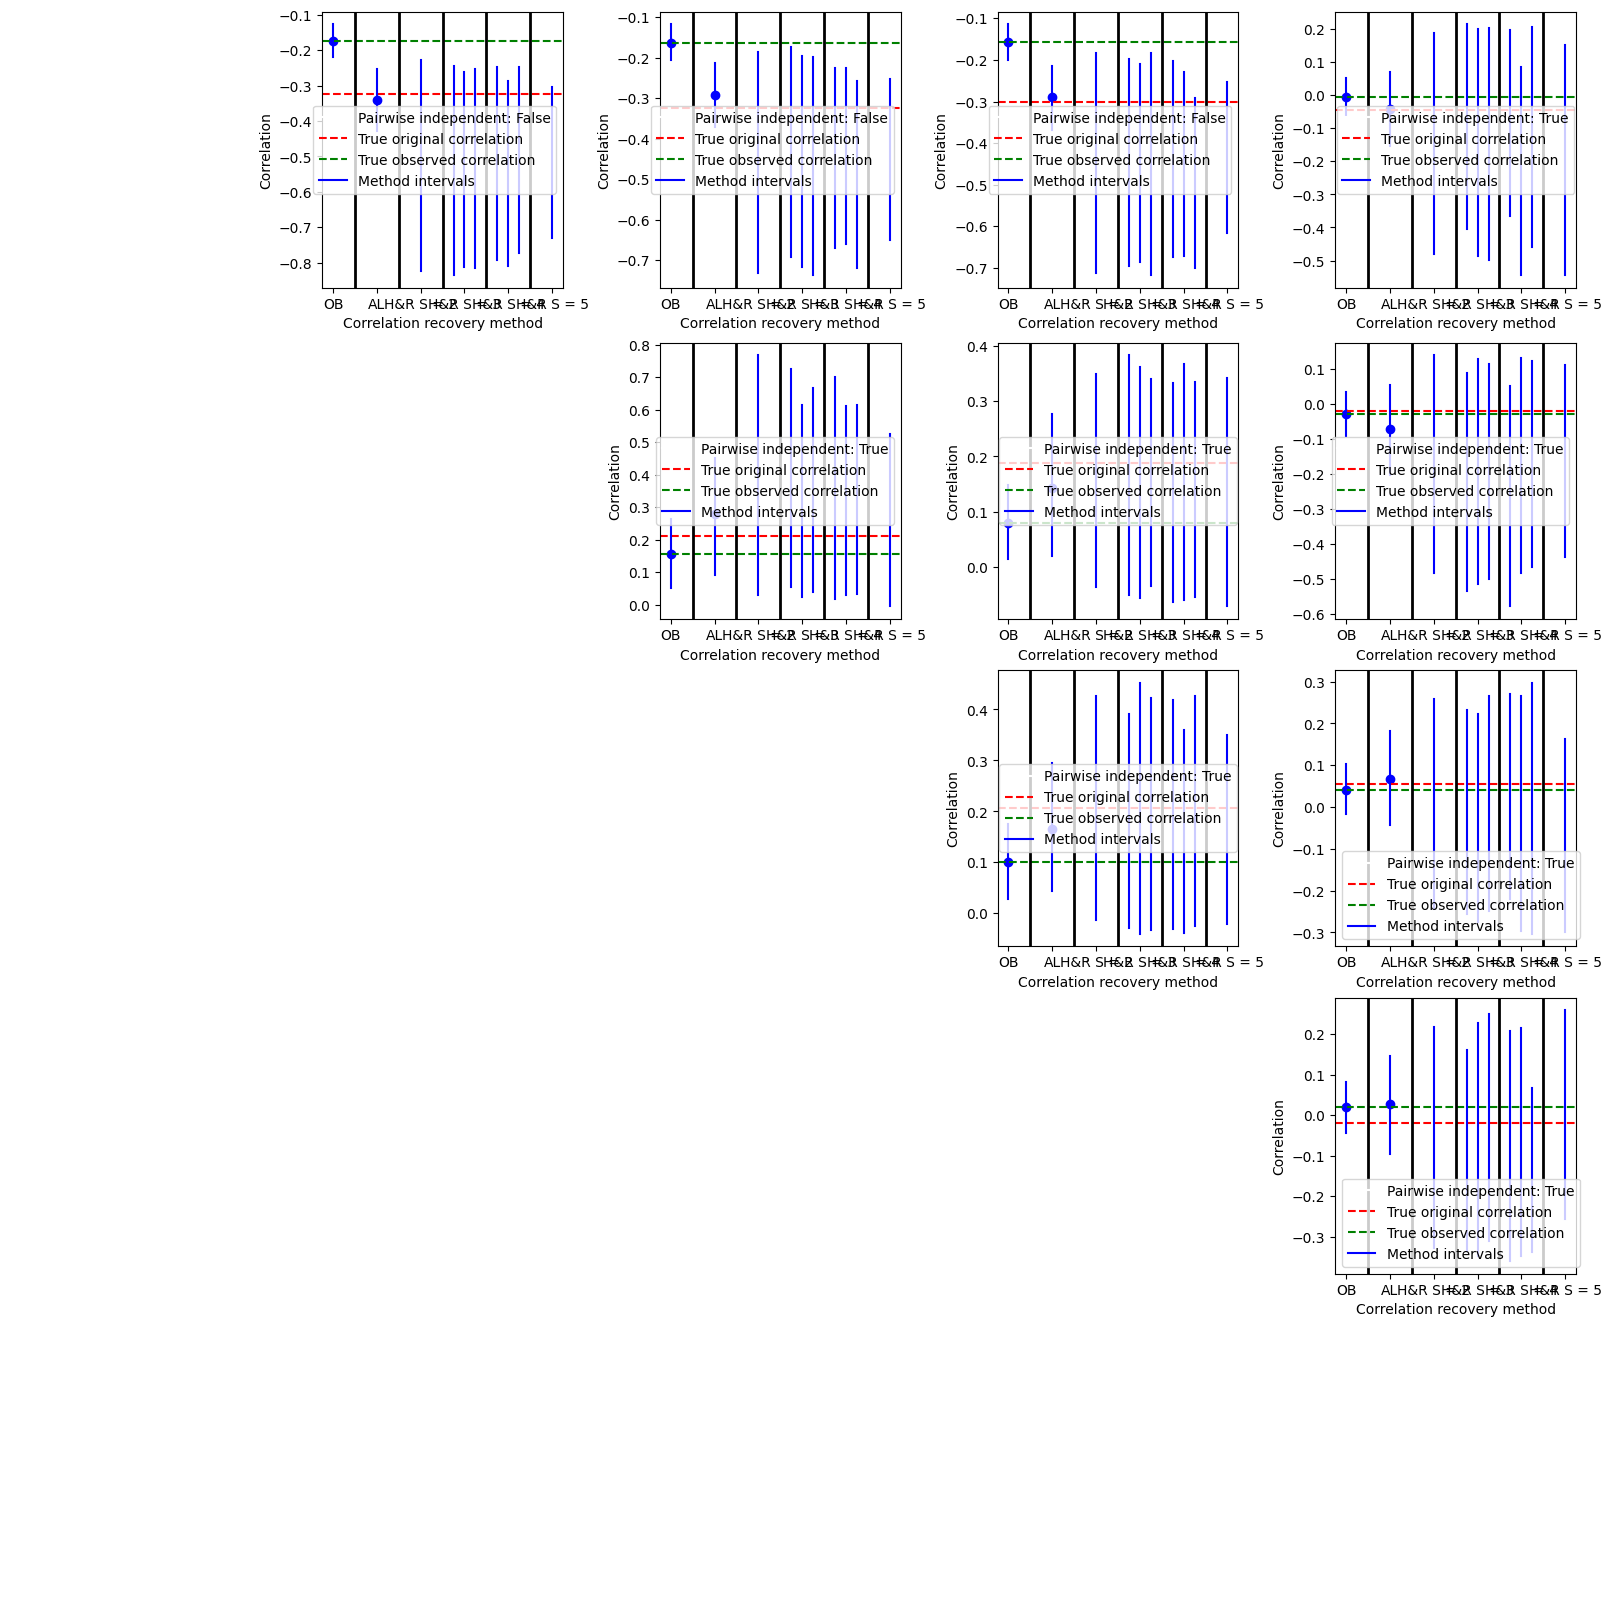

In [242]:
fig, axs = plt.subplots(D, D, squeeze=False, figsize=(16, 16), constrained_layout=True)

for i in range(D):
    for j in range(D):

        if j <= i:
            axs[i, j].axis('off')
            continue

        # independence test
        axs[i, j].plot([], [], label=f"Pairwise independent: {results[i, j]['independent']}", color="white")

        # true correlations
        axs[i, j].axhline(correlation_matrix_original[i, j], linestyle="--", color="red", label="True original correlation")
        axs[i, j].axhline(correlation_matrix_observed[i, j], linestyle="--", color="green", label="True observed correlation")

        #OB
        axs[i, j].plot([0.5]*2, results[i, j]['OB'][1:], color="blue", label="Method intervals")
        axs[i, j].scatter([0.5], results[i, j]['OB'][0], color="blue")

        # AL
        axs[i, j].plot([1.5]*2, results[i, j]['AL'][1:], color="blue")
        axs[i, j].scatter([1.5], results[i, j]['AL'][0], color="blue")

        # H&R intervals
        for S in range(2, D + 1):
            intervals = results[i, j][S]
            K = len(intervals) + 1
            for k, interval in enumerate(intervals):
                axs[i, j].plot([S + ((k + 1) / K)]*2, interval[1:], color="blue")
                #axs[i, j].scatter([S + ((k + 1) / K)], interval[0], color="blue")

        # dividers
        for k in range(1, D + 1):
            axs[i, j].axvline(k, color="black", lw=2)

        # labels
        axs[i, j].set_ylabel("Correlation")
        axs[i, j].set_xticks([k + 0.5 for k in range(D + 1)])
        axs[i, j].set_xticklabels(["OB", "AL"] + [f"H&R S = {S}" for S in range(2, D + 1)])
        axs[i, j].set_xlabel("Correlation recovery method")
        axs[i, j].legend()

### Stacked plot

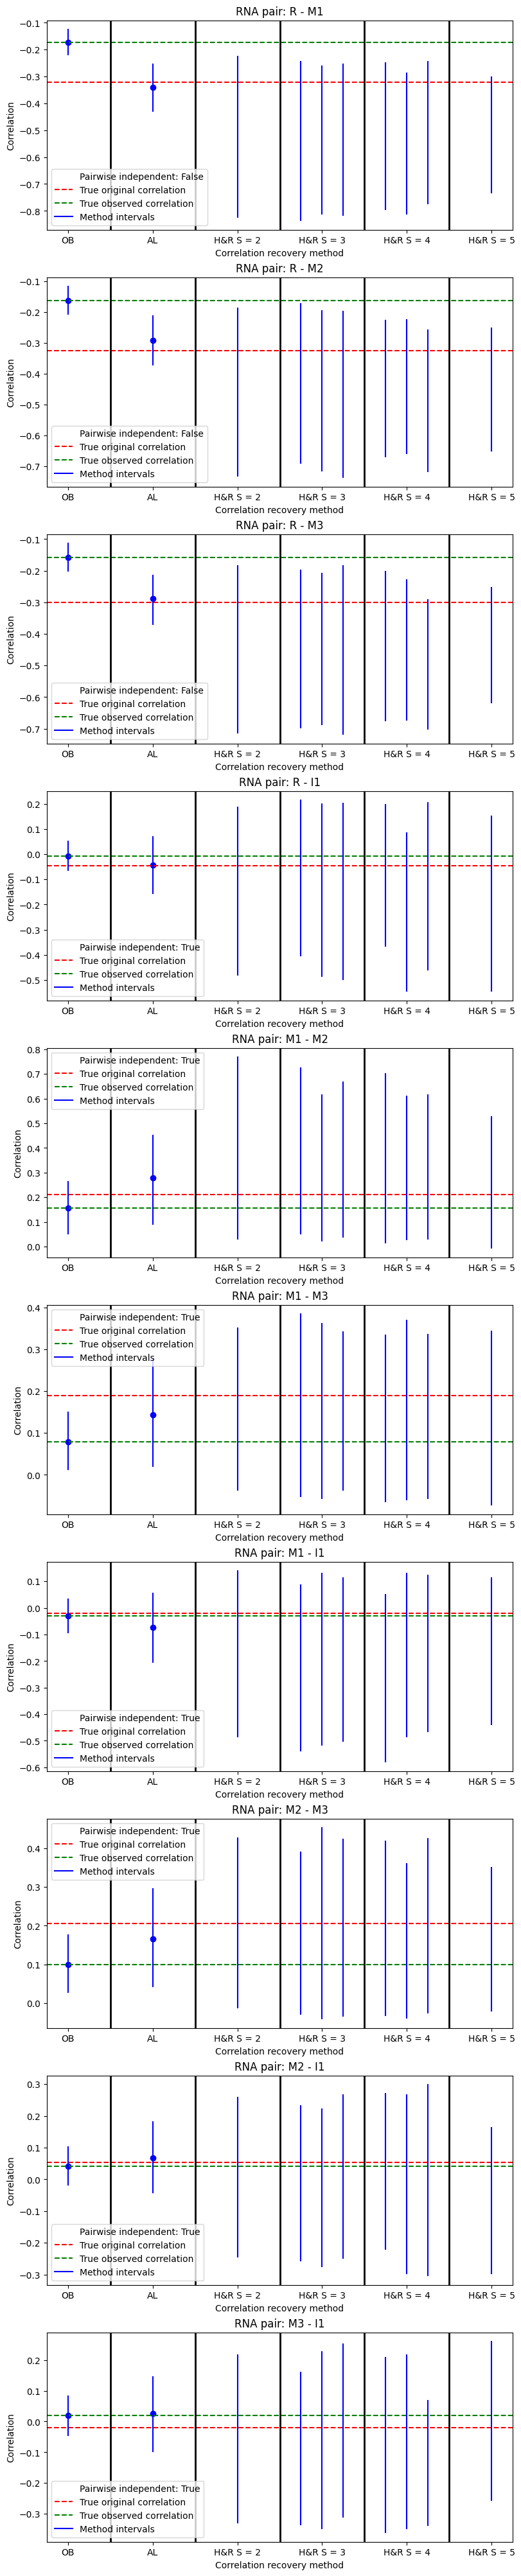

In [243]:
M = D * (D - 1) // 2

fig, axs = plt.subplots(M, 1, squeeze=False, figsize=(8, 4 * M), constrained_layout=True)

m = 0
for i in range(D):
    for j in range(i + 1, D):

        # independence test
        axs[m, 0].plot([], [], label=f"Pairwise independent: {results[i, j]['independent']}", color="white")

        # true correlations
        axs[m, 0].axhline(correlation_matrix_original[i, j], linestyle="--", color="red", label="True original correlation")
        axs[m, 0].axhline(correlation_matrix_observed[i, j], linestyle="--", color="green", label="True observed correlation")

        #OB
        axs[m, 0].plot([0.5]*2, results[i, j]['OB'][1:], color="blue", label="Method intervals")
        axs[m, 0].scatter([0.5], results[i, j]['OB'][0], color="blue")

        # AL
        axs[m, 0].plot([1.5]*2, results[i, j]['AL'][1:], color="blue")
        axs[m, 0].scatter([1.5], results[i, j]['AL'][0], color="blue")

        # H&R intervals
        for S in range(2, D + 1):
            intervals = results[i, j][S]
            K = len(intervals) + 1
            for k, interval in enumerate(intervals):
                axs[m, 0].plot([S + ((k + 1) / K)]*2, interval[1:], color="blue")
                #axs[m, 0].scatter([S + ((k + 1) / K)], interval[0], color="blue")

        # dividers
        for k in range(1, D + 1):
            axs[m, 0].axvline(k, color="black", lw=2)

        # labels
        axs[m, 0].set_ylabel("Correlation")
        axs[m, 0].set_xticks([k + 0.5 for k in range(D + 1)])
        axs[m, 0].set_xticklabels(["OB", "AL"] + [f"H&R S = {S}" for S in range(2, D + 1)])
        axs[m, 0].set_xlabel("Correlation recovery method")
        axs[m, 0].legend()

        # title
        axs[m, 0].set_title(f"RNA pair: {RNA_labels[i]} - {RNA_labels[j]}")

        m += 1

### Coverage statistics

In [267]:
coverage_list = []
for S in range(2, D + 1):
    coverage = []
    for i in range(D):
        for j in range(i + 1, D):
            for interval in results[i, j][S]:
                if interval[1] <= correlation_matrix_original[i, j] and interval[2] >= correlation_matrix_original[i, j]:
                    coverage.append(1)
                else:
                    coverage.append(0)                  
    coverage_list.append(float(np.mean(coverage)))

In [269]:
coverage_list

[1.0, 1.0, 1.0, 1.0]

### Width statistics

In [247]:
widths_list = []
for S in range(2, D + 1):
    widths = []
    for i in range(D):
        for j in range(i + 1, D):
            for interval in results[i, j][S]:
                widths.append(interval[2] - interval[1])
    widths_list.append(widths)

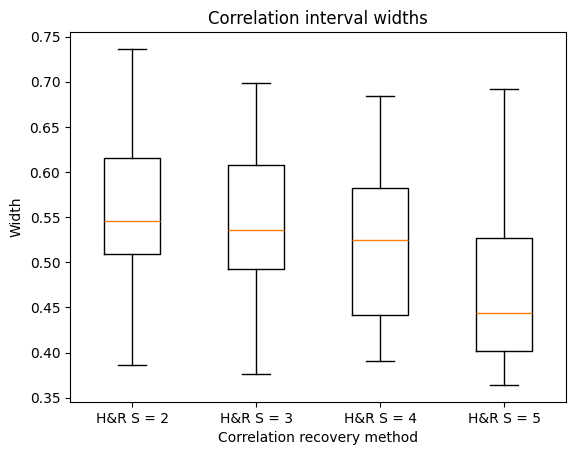

In [263]:
fig, axs = plt.subplots()
axs.boxplot(widths_list);
axs.set_xticklabels([f"H&R S = {S}" for S in range(2, D + 1)])
axs.set_ylabel("Width")
axs.set_xlabel("Correlation recovery method")
axs.set_title("Correlation interval widths")
plt.show()

# (2) Simulated data: {mRNA} - {miRNA regulators}

## Simulate data

In [300]:
regulators = 3
k_tx = 5
k_deg = 1
k_reg = 5

stoch_inp = np.zeros((2 + regulators * 3, 1 + regulators))
stoch_out = np.zeros((2 + regulators * 3, 1 + regulators))
rates = np.ones(2 + 3 * regulators)

# mRNA tx and deg reactions
stoch_out[0, 0] = 1
rates[0] = k_tx
stoch_inp[1, 0] = 1
rates[1] = k_deg

for m in range(regulators):

    r = 2 + 3 * m
    s = 1 + m

    # miRNA tx and deg reactions
    stoch_out[r, s] = 1
    rates[r] = k_tx
    stoch_inp[r + 1, s] = 1
    rates[r + 1] = k_deg

    # mRNA - miRNA interaction
    stoch_inp[r + 2, 0] = 1
    stoch_inp[r + 2, s] = 1
    #stoch_out[r + 2, s] = 1
    rates[r + 2] = k_reg

In [301]:
initial = None
tmax = 10100
tmin = 100
tint = 10
n = 1000

# run gillespie
path, path_times = SDP_miRNA.simulation.gillespie(stoch_inp, stoch_out, rates, initial, tmax)

In [304]:
# take samples at uniform time points
sample = SDP_miRNA.simulation.uniform_time_samples(path, path_times, tmin=tmin, tmax=tmax, tint=tint, n=n)

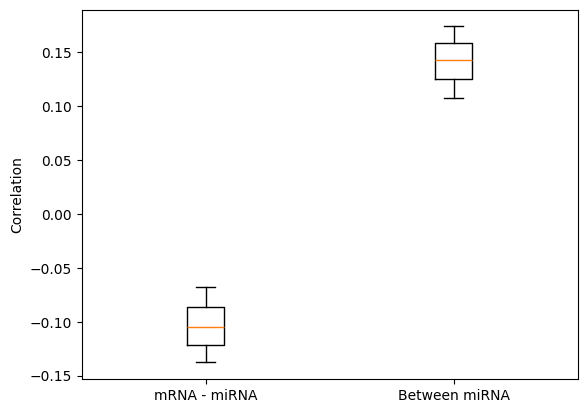

In [ ]:
# compute correlations
corr_mRNA, corr_miRNA = correlation_point(sample)

# display
fig, axs = plt.subplots()
axs.boxplot([corr_mRNA, corr_miRNA], positions=[0, 1])
axs.set_xticklabels(["mRNA - miRNA", "Between miRNA"])
axs.set_ylabel("Correlation")
plt.show()

In [306]:
# simulate independent RNA
RNA_indep = rng.poisson(k_tx / k_deg, size=n).reshape(-1, 1)

# construct full data
RNA_data_original = np.hstack([sample, RNA_indep]).astype(np.int64)

In [307]:
# capture
mean_capture = 0.5
capture_shape = 30
capture_scale = (capture_shape / mean_capture) * (1 - mean_capture)

# sample capture
beta = rng.beta(capture_shape, capture_scale, size=n)

# downsample
RNA_data = rng.binomial(RNA_data_original, beta[:, None])

## Display correlations

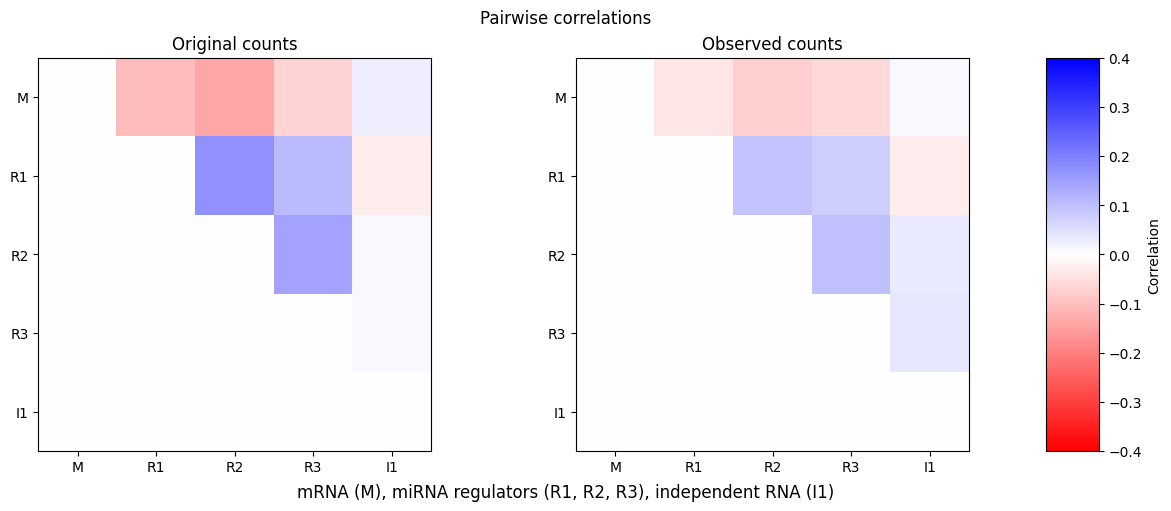

In [308]:
# compute original and observed data point correlations
correlation_matrix_original = np.corrcoef(RNA_data_original.T)
correlation_matrix_observed = np.corrcoef(RNA_data.T)

# remove redundant values
correlation_matrix_original[np.tril_indices(correlation_matrix_original.shape[0], k=0)] = 0
correlation_matrix_observed[np.tril_indices(correlation_matrix_observed.shape[0], k=0)] = 0

# display
RNA_labels = ["M", "R1", "R2", "R3", "I1"]
cmap = LinearSegmentedColormap.from_list('a', ['red', 'white', 'blue'])
fig, axs = plt.subplots(1, 3, figsize=(12, 5), gridspec_kw={'width_ratios': [1, 1, 0.1]}, constrained_layout=True)
im = axs[0].imshow(correlation_matrix_original, cmap=cmap, vmin=-0.4, vmax=0.4)
im = axs[1].imshow(correlation_matrix_observed, cmap=cmap, vmin=-0.4, vmax=0.4)
axs[0].set_title("Original counts")
axs[0].set_xticks(range(5))
axs[0].set_xticklabels(RNA_labels)
axs[0].set_yticks(range(5))
axs[0].set_yticklabels(RNA_labels)
axs[1].set_title("Observed counts")
axs[1].set_xticks(range(5))
axs[1].set_xticklabels(RNA_labels)
axs[1].set_yticks(range(5))
axs[1].set_yticklabels(RNA_labels)
fig.suptitle("Pairwise correlations")
fig.supxlabel("mRNA (M), miRNA regulators (R1, R2, R3), independent RNA (I1)")
plt.colorbar(im, cax=axs[2], label="Correlation")
plt.show()

## Optimize

In [309]:
# construct dataset
data_SDP = SDP_miRNA.dataset.Dataset()

# duplicate full data (miRNA + mRNA) for easy indexing
data_SDP.construct_dataset_array(
    RNA_data,
    RNA_data,
    beta
)

# total species
D = RNA_data.shape[1]

In [310]:
# store results
results = np.empty((D, D), dtype=object)
for i in range(D):
    for j in range(i + 1, D):
        results[i, j] = {S: [] for S in range(2, D + 1)}

In [311]:
# settings
d = 3

# for each number of species
for S in range(2, D + 1):

    # get all unique species selections
    combs = list(combinations(range(D), r=S))

    # construct gene queries (index all from sparse_A)
    gene_queries = [
        [list(idxs), []] for idxs in combs
    ]

    # update dataset
    data_SDP.gene_queries = gene_queries
    data_SDP.total_gene_queries = len(gene_queries)

    # bootstrap
    data_SDP.bootstrap(d=d)

    # Model Free Interacting test
    MF_int = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(data_SDP, d=d)
    MF_int.analyse_dataset()

    # compute pairwise correlations from H&R samples
    for sx in range(S):
        for sy in range(sx + 1, S):
            _, HAR_interval = MF_int.compute_dataset_correlation(Sx=sx, Sy=sy)
            HAR_midpoint = (HAR_interval[:, 0] + HAR_interval[:, 1]) / 2

            # store point & intervals
            for i, query in enumerate(gene_queries):
                results[query[0][sx], query[0][sy]][S].append(np.array([HAR_midpoint[i], HAR_interval[i, 0], HAR_interval[i, 1]]))

100%|██████████| 1/1 [00:00<00:00, 10.52it/s]


In [312]:
# pairwise independence test & analytic correlation

# get indices (need to use sparse_A & sparse_B or else correlation complains)
Is, Js = np.triu_indices(D, k=1)
gene_queries = [
    [[int(i)], [int(j)]] for i, j in zip(Is, Js)
]

# update dataset
data_SDP.gene_queries = gene_queries
data_SDP.total_gene_queries = len(gene_queries)

# bootstrap
data_SDP.bootstrap(d=d)

# Model Free Independence test
MF_ind = SDP_miRNA.optimization.ModelFreeOptimization(data_SDP, d=d)
MF_ind.analyse_dataset()

# store status
for i, query in enumerate(gene_queries):
    status = (MF_ind.result_dict[i]['status'] == "OPTIMAL")
    results[query[0][0], query[1][0]]['independent'] = status

# analytic correlation
OB, AL = SDP_miRNA.correlation.compute_correlations(data_SDP)

# store point & intervals
for i, query in enumerate(gene_queries):
    results[query[0][0], query[1][0]]['OB'] = OB[i, :]
    results[query[0][0], query[1][0]]['AL'] = AL[i, :]

100%|██████████| 1/1 [00:00<00:00, 44.21it/s]


## Display results

### Single pair

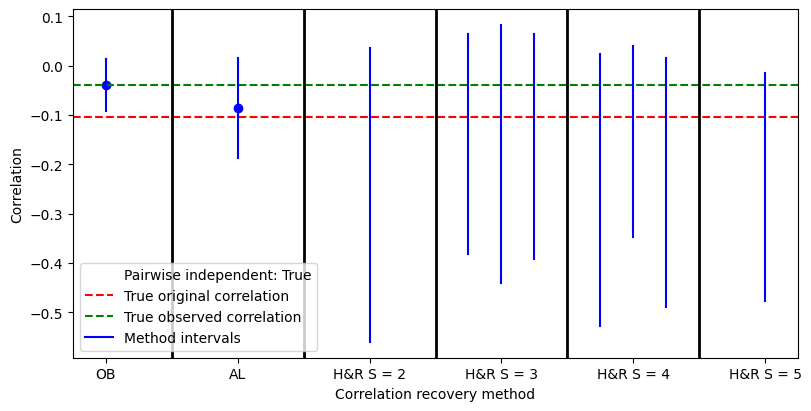

In [313]:
i, j = 0, 1

fig, axs = plt.subplots(1, 1, squeeze=False, figsize=(8, 4), constrained_layout=True)

# independence test
axs[0, 0].plot([], [], label=f"Pairwise independent: {results[i, j]['independent']}", color="white")

# true correlations
axs[0, 0].axhline(correlation_matrix_original[i, j], linestyle="--", color="red", label="True original correlation")
axs[0, 0].axhline(correlation_matrix_observed[i, j], linestyle="--", color="green", label="True observed correlation")

#OB
axs[0, 0].plot([0.5]*2, results[i, j]['OB'][1:], color="blue", label="Method intervals")
axs[0, 0].scatter([0.5], results[i, j]['OB'][0], color="blue")

# AL
axs[0, 0].plot([1.5]*2, results[i, j]['AL'][1:], color="blue")
axs[0, 0].scatter([1.5], results[i, j]['AL'][0], color="blue")

# H&R intervals
for S in range(2, D + 1):
    intervals = results[i, j][S]
    K = len(intervals) + 1
    for k, interval in enumerate(intervals):
        axs[0, 0].plot([S + ((k + 1) / K)]*2, interval[1:], color="blue")
        #axs[0, 0].scatter([S + ((k + 1) / K)], interval[0], color="blue")

# dividers
for k in range(1, D + 1):
    axs[0, 0].axvline(k, color="black", lw=2)

# labels
axs[0, 0].set_ylabel("Correlation")
axs[0, 0].set_xticks([k + 0.5 for k in range(D + 1)])
axs[0, 0].set_xticklabels(["OB", "AL"] + [f"H&R S = {S}" for S in range(2, D + 1)])
axs[0, 0].set_xlabel("Correlation recovery method")
axs[0, 0].legend()

### Gridplot

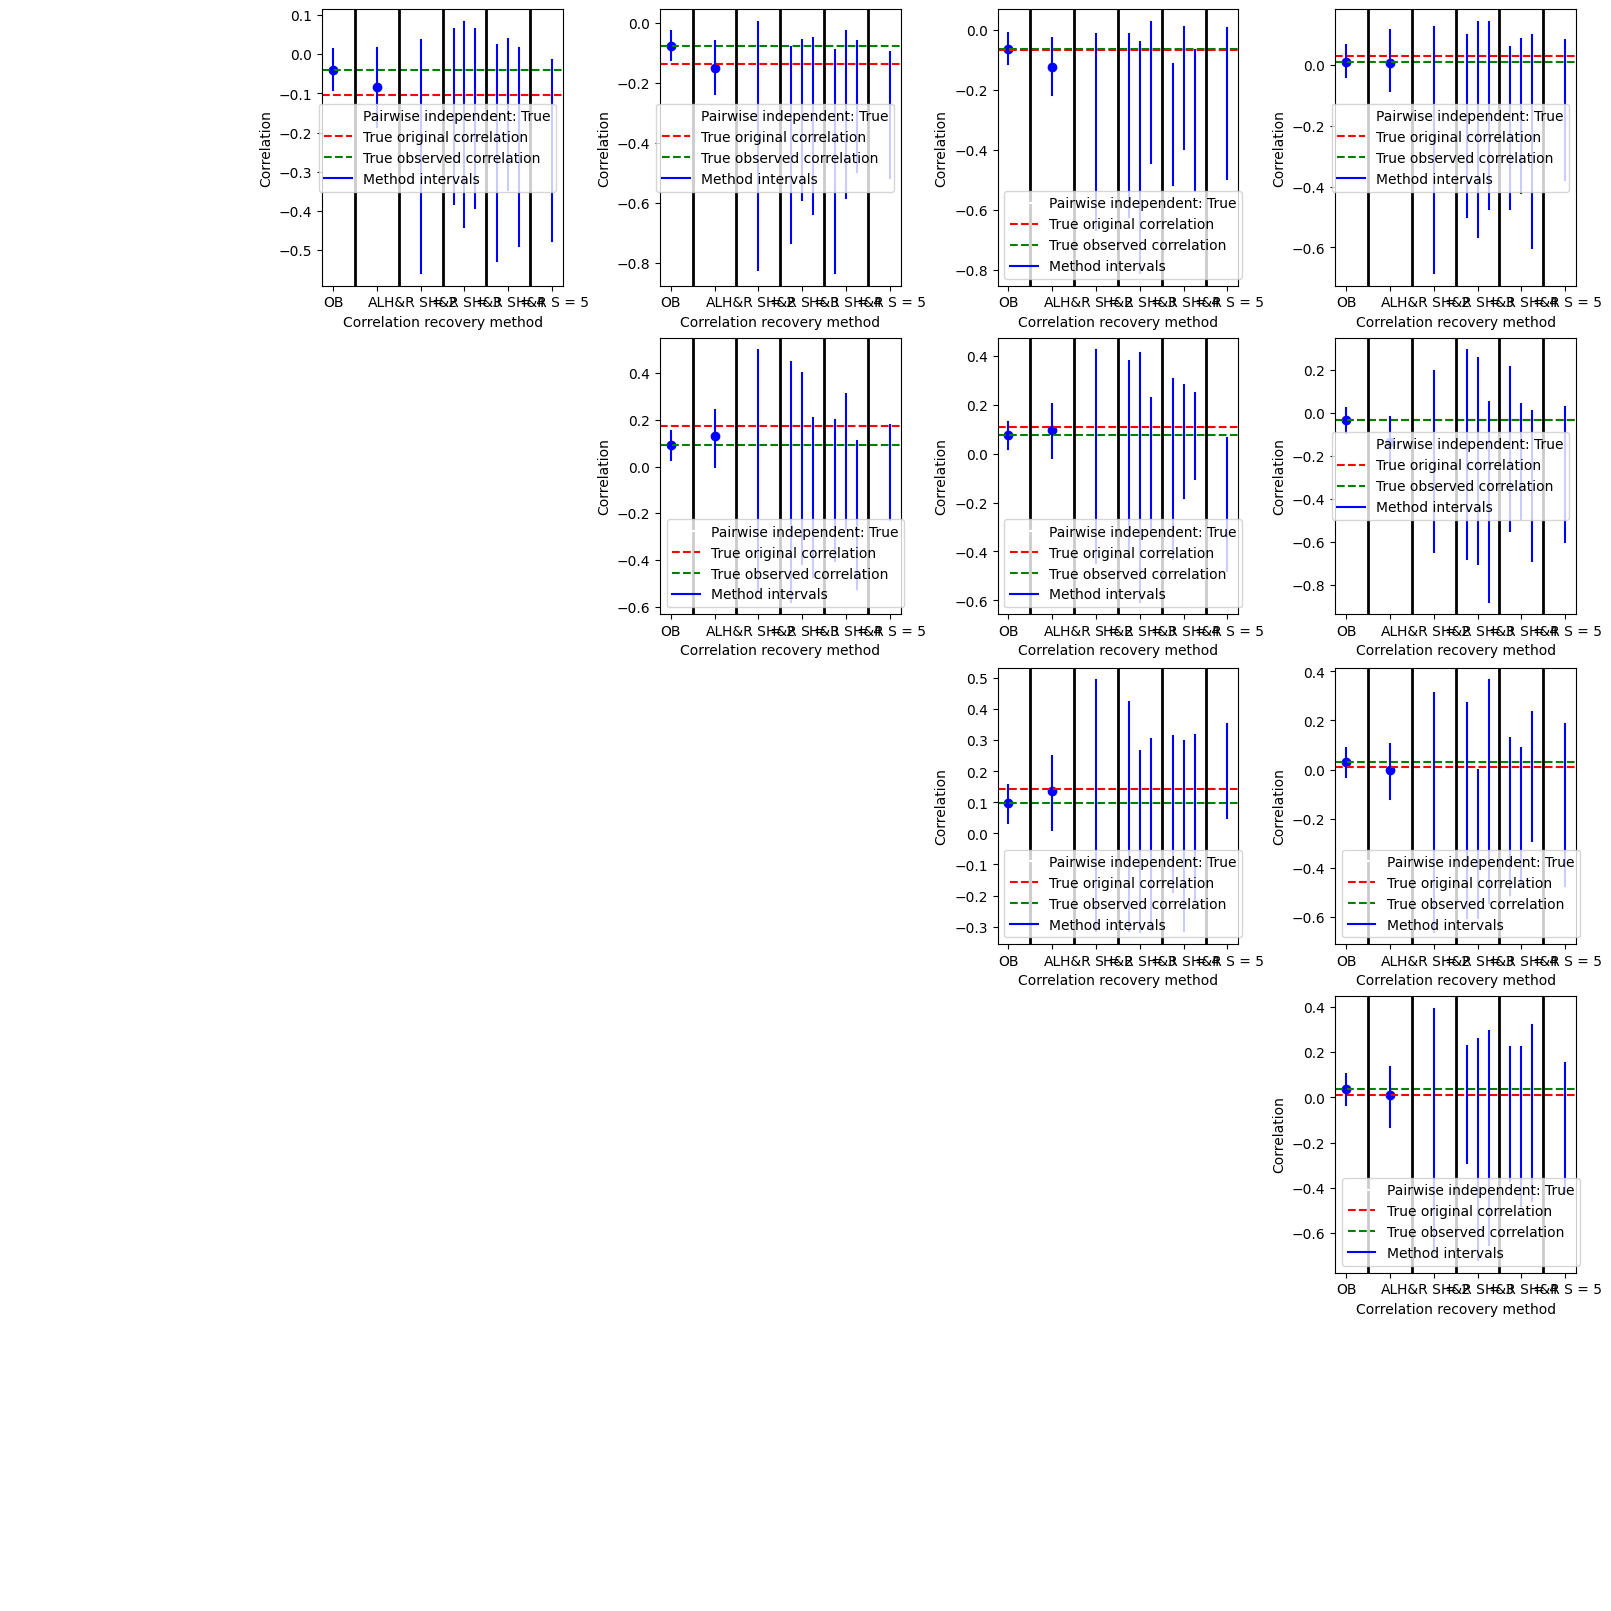

In [314]:
fig, axs = plt.subplots(D, D, squeeze=False, figsize=(16, 16), constrained_layout=True)

for i in range(D):
    for j in range(D):

        if j <= i:
            axs[i, j].axis('off')
            continue

        # independence test
        axs[i, j].plot([], [], label=f"Pairwise independent: {results[i, j]['independent']}", color="white")

        # true correlations
        axs[i, j].axhline(correlation_matrix_original[i, j], linestyle="--", color="red", label="True original correlation")
        axs[i, j].axhline(correlation_matrix_observed[i, j], linestyle="--", color="green", label="True observed correlation")

        #OB
        axs[i, j].plot([0.5]*2, results[i, j]['OB'][1:], color="blue", label="Method intervals")
        axs[i, j].scatter([0.5], results[i, j]['OB'][0], color="blue")

        # AL
        axs[i, j].plot([1.5]*2, results[i, j]['AL'][1:], color="blue")
        axs[i, j].scatter([1.5], results[i, j]['AL'][0], color="blue")

        # H&R intervals
        for S in range(2, D + 1):
            intervals = results[i, j][S]
            K = len(intervals) + 1
            for k, interval in enumerate(intervals):
                axs[i, j].plot([S + ((k + 1) / K)]*2, interval[1:], color="blue")
                #axs[i, j].scatter([S + ((k + 1) / K)], interval[0], color="blue")

        # dividers
        for k in range(1, D + 1):
            axs[i, j].axvline(k, color="black", lw=2)

        # labels
        axs[i, j].set_ylabel("Correlation")
        axs[i, j].set_xticks([k + 0.5 for k in range(D + 1)])
        axs[i, j].set_xticklabels(["OB", "AL"] + [f"H&R S = {S}" for S in range(2, D + 1)])
        axs[i, j].set_xlabel("Correlation recovery method")
        axs[i, j].legend()

### Stacked plot

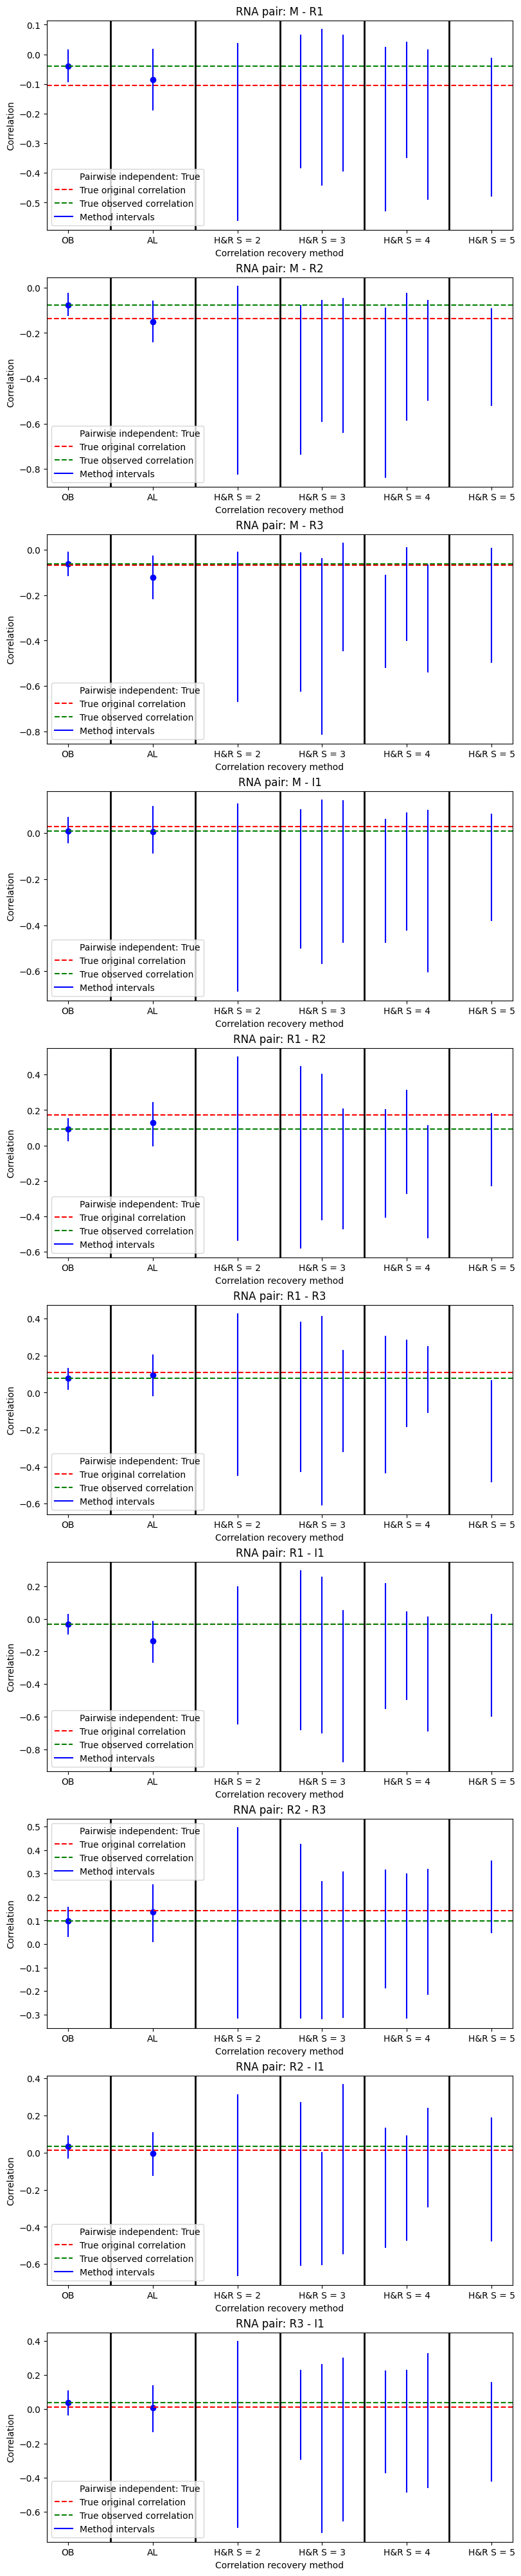

In [315]:
M = D * (D - 1) // 2

fig, axs = plt.subplots(M, 1, squeeze=False, figsize=(8, 4 * M), constrained_layout=True)

m = 0
for i in range(D):
    for j in range(i + 1, D):

        # independence test
        axs[m, 0].plot([], [], label=f"Pairwise independent: {results[i, j]['independent']}", color="white")

        # true correlations
        axs[m, 0].axhline(correlation_matrix_original[i, j], linestyle="--", color="red", label="True original correlation")
        axs[m, 0].axhline(correlation_matrix_observed[i, j], linestyle="--", color="green", label="True observed correlation")

        #OB
        axs[m, 0].plot([0.5]*2, results[i, j]['OB'][1:], color="blue", label="Method intervals")
        axs[m, 0].scatter([0.5], results[i, j]['OB'][0], color="blue")

        # AL
        axs[m, 0].plot([1.5]*2, results[i, j]['AL'][1:], color="blue")
        axs[m, 0].scatter([1.5], results[i, j]['AL'][0], color="blue")

        # H&R intervals
        for S in range(2, D + 1):
            intervals = results[i, j][S]
            K = len(intervals) + 1
            for k, interval in enumerate(intervals):
                axs[m, 0].plot([S + ((k + 1) / K)]*2, interval[1:], color="blue")
                #axs[m, 0].scatter([S + ((k + 1) / K)], interval[0], color="blue")

        # dividers
        for k in range(1, D + 1):
            axs[m, 0].axvline(k, color="black", lw=2)

        # labels
        axs[m, 0].set_ylabel("Correlation")
        axs[m, 0].set_xticks([k + 0.5 for k in range(D + 1)])
        axs[m, 0].set_xticklabels(["OB", "AL"] + [f"H&R S = {S}" for S in range(2, D + 1)])
        axs[m, 0].set_xlabel("Correlation recovery method")
        axs[m, 0].legend()

        # title
        axs[m, 0].set_title(f"RNA pair: {RNA_labels[i]} - {RNA_labels[j]}")

        m += 1

### Coverage statistics

In [319]:
coverage_list = []
for S in range(2, D + 1):
    coverage = []
    for i in range(D):
        for j in range(i + 1, D):
            for interval in results[i, j][S]:
                if interval[1] <= correlation_matrix_original[i, j] and interval[2] >= correlation_matrix_original[i, j]:
                    coverage.append(1)
                else:
                    coverage.append(0)                  
    coverage_list.append(float(np.mean(coverage)))

In [320]:
coverage_list

[1.0, 0.9666666666666667, 0.9, 0.9]

### Width statistics

In [321]:
widths_list = []
for S in range(2, D + 1):
    widths = []
    for i in range(D):
        for j in range(i + 1, D):
            for interval in results[i, j][S]:
                widths.append(interval[2] - interval[1])
    widths_list.append(widths)

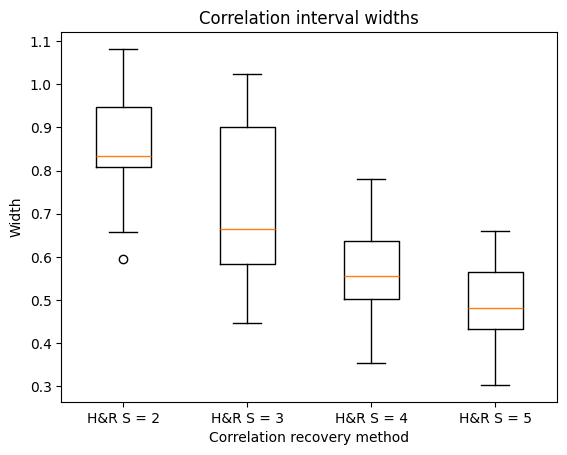

In [322]:
fig, axs = plt.subplots()
axs.boxplot(widths_list);
axs.set_xticklabels([f"H&R S = {S}" for S in range(2, D + 1)])
axs.set_ylabel("Width")
axs.set_xlabel("Correlation recovery method")
axs.set_title("Correlation interval widths")
plt.show()

## Repeat with more H&R samples

In [323]:
# construct dataset
data_SDP = SDP_miRNA.dataset.Dataset()

# duplicate full data (miRNA + mRNA) for easy indexing
data_SDP.construct_dataset_array(
    RNA_data,
    RNA_data,
    beta
)

# total species
D = RNA_data.shape[1]

In [324]:
# store results
results = np.empty((D, D), dtype=object)
for i in range(D):
    for j in range(i + 1, D):
        results[i, j] = {S: [] for S in range(2, D + 1)}

In [325]:
# settings
d = 3

# for each number of species
for S in range(2, D + 1):

    # get all unique species selections
    combs = list(combinations(range(D), r=S))

    # construct gene queries (index all from sparse_A)
    gene_queries = [
        [list(idxs), []] for idxs in combs
    ]

    # update dataset
    data_SDP.gene_queries = gene_queries
    data_SDP.total_gene_queries = len(gene_queries)

    # bootstrap
    data_SDP.bootstrap(d=d)

    # Model Free Interacting test
    MF_int = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(data_SDP, d=d, N=10000)
    MF_int.analyse_dataset()

    # compute pairwise correlations from H&R samples
    for sx in range(S):
        for sy in range(sx + 1, S):
            _, HAR_interval = MF_int.compute_dataset_correlation(Sx=sx, Sy=sy)
            HAR_midpoint = (HAR_interval[:, 0] + HAR_interval[:, 1]) / 2

            # store point & intervals
            for i, query in enumerate(gene_queries):
                results[query[0][sx], query[0][sy]][S].append(np.array([HAR_midpoint[i], HAR_interval[i, 0], HAR_interval[i, 1]]))

100%|██████████| 1/1 [00:01<00:00,  1.05s/it]


In [326]:
# pairwise independence test & analytic correlation

# get indices (need to use sparse_A & sparse_B or else correlation complains)
Is, Js = np.triu_indices(D, k=1)
gene_queries = [
    [[int(i)], [int(j)]] for i, j in zip(Is, Js)
]

# update dataset
data_SDP.gene_queries = gene_queries
data_SDP.total_gene_queries = len(gene_queries)

# bootstrap
data_SDP.bootstrap(d=d)

# Model Free Independence test
MF_ind = SDP_miRNA.optimization.ModelFreeOptimization(data_SDP, d=d)
MF_ind.analyse_dataset()

# store status
for i, query in enumerate(gene_queries):
    status = (MF_ind.result_dict[i]['status'] == "OPTIMAL")
    results[query[0][0], query[1][0]]['independent'] = status

# analytic correlation
OB, AL = SDP_miRNA.correlation.compute_correlations(data_SDP)

# store point & intervals
for i, query in enumerate(gene_queries):
    results[query[0][0], query[1][0]]['OB'] = OB[i, :]
    results[query[0][0], query[1][0]]['AL'] = AL[i, :]

100%|██████████| 1/1 [00:00<00:00, 39.09it/s]


### Single pair

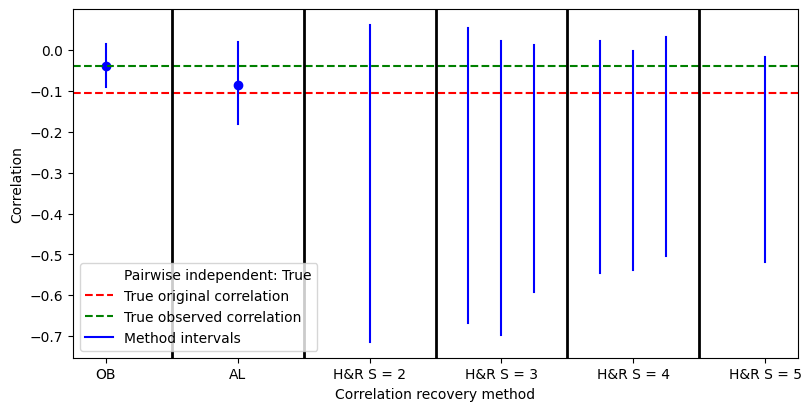

In [327]:
i, j = 0, 1

fig, axs = plt.subplots(1, 1, squeeze=False, figsize=(8, 4), constrained_layout=True)

# independence test
axs[0, 0].plot([], [], label=f"Pairwise independent: {results[i, j]['independent']}", color="white")

# true correlations
axs[0, 0].axhline(correlation_matrix_original[i, j], linestyle="--", color="red", label="True original correlation")
axs[0, 0].axhline(correlation_matrix_observed[i, j], linestyle="--", color="green", label="True observed correlation")

#OB
axs[0, 0].plot([0.5]*2, results[i, j]['OB'][1:], color="blue", label="Method intervals")
axs[0, 0].scatter([0.5], results[i, j]['OB'][0], color="blue")

# AL
axs[0, 0].plot([1.5]*2, results[i, j]['AL'][1:], color="blue")
axs[0, 0].scatter([1.5], results[i, j]['AL'][0], color="blue")

# H&R intervals
for S in range(2, D + 1):
    intervals = results[i, j][S]
    K = len(intervals) + 1
    for k, interval in enumerate(intervals):
        axs[0, 0].plot([S + ((k + 1) / K)]*2, interval[1:], color="blue")
        #axs[0, 0].scatter([S + ((k + 1) / K)], interval[0], color="blue")

# dividers
for k in range(1, D + 1):
    axs[0, 0].axvline(k, color="black", lw=2)

# labels
axs[0, 0].set_ylabel("Correlation")
axs[0, 0].set_xticks([k + 0.5 for k in range(D + 1)])
axs[0, 0].set_xticklabels(["OB", "AL"] + [f"H&R S = {S}" for S in range(2, D + 1)])
axs[0, 0].set_xlabel("Correlation recovery method")
axs[0, 0].legend()

### Gridplot

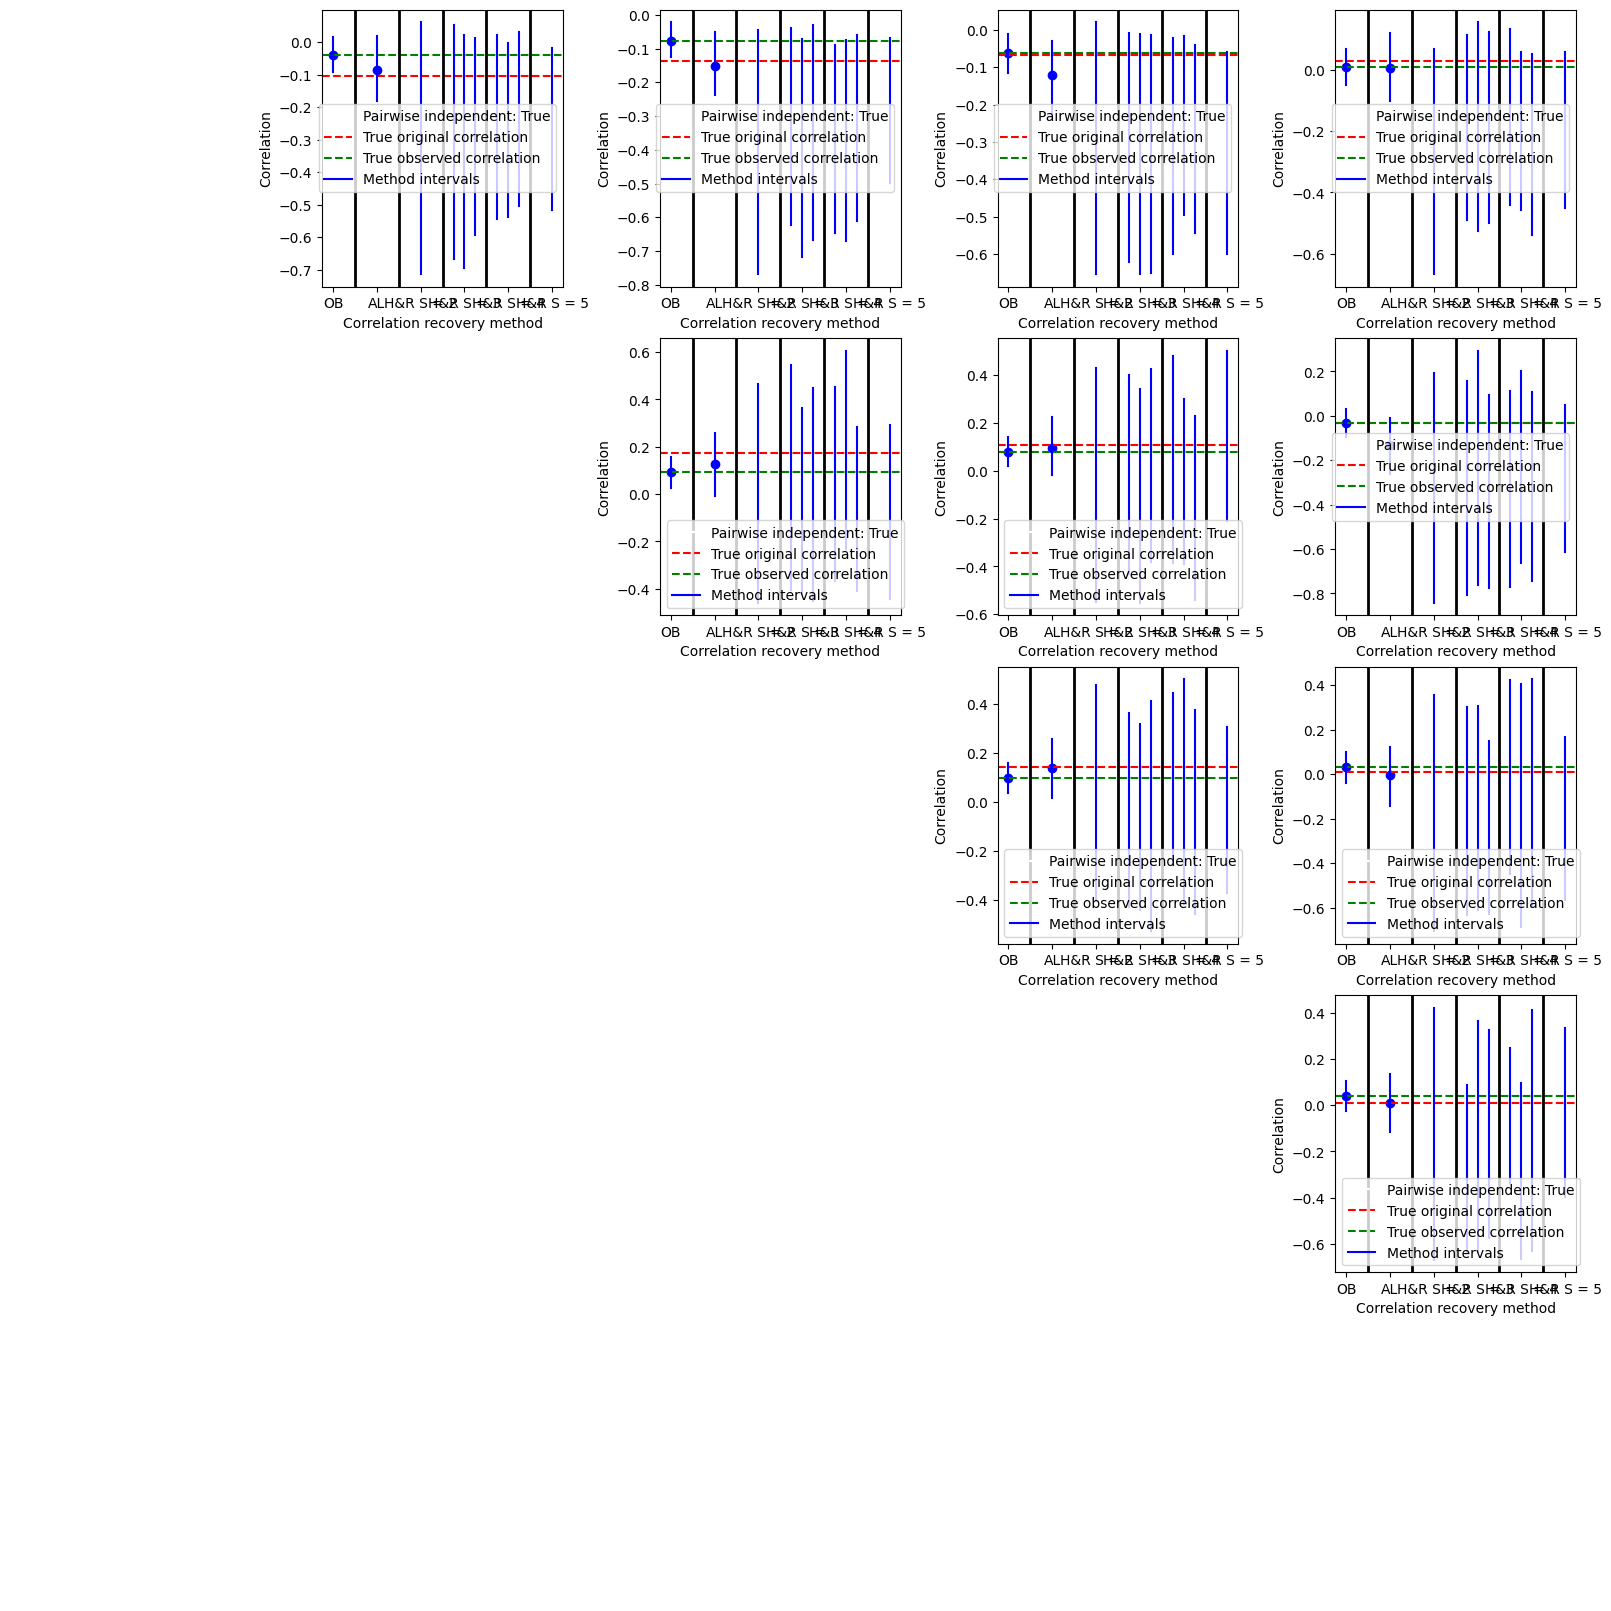

In [328]:
fig, axs = plt.subplots(D, D, squeeze=False, figsize=(16, 16), constrained_layout=True)

for i in range(D):
    for j in range(D):

        if j <= i:
            axs[i, j].axis('off')
            continue

        # independence test
        axs[i, j].plot([], [], label=f"Pairwise independent: {results[i, j]['independent']}", color="white")

        # true correlations
        axs[i, j].axhline(correlation_matrix_original[i, j], linestyle="--", color="red", label="True original correlation")
        axs[i, j].axhline(correlation_matrix_observed[i, j], linestyle="--", color="green", label="True observed correlation")

        #OB
        axs[i, j].plot([0.5]*2, results[i, j]['OB'][1:], color="blue", label="Method intervals")
        axs[i, j].scatter([0.5], results[i, j]['OB'][0], color="blue")

        # AL
        axs[i, j].plot([1.5]*2, results[i, j]['AL'][1:], color="blue")
        axs[i, j].scatter([1.5], results[i, j]['AL'][0], color="blue")

        # H&R intervals
        for S in range(2, D + 1):
            intervals = results[i, j][S]
            K = len(intervals) + 1
            for k, interval in enumerate(intervals):
                axs[i, j].plot([S + ((k + 1) / K)]*2, interval[1:], color="blue")
                #axs[i, j].scatter([S + ((k + 1) / K)], interval[0], color="blue")

        # dividers
        for k in range(1, D + 1):
            axs[i, j].axvline(k, color="black", lw=2)

        # labels
        axs[i, j].set_ylabel("Correlation")
        axs[i, j].set_xticks([k + 0.5 for k in range(D + 1)])
        axs[i, j].set_xticklabels(["OB", "AL"] + [f"H&R S = {S}" for S in range(2, D + 1)])
        axs[i, j].set_xlabel("Correlation recovery method")
        axs[i, j].legend()

### Stacked plot

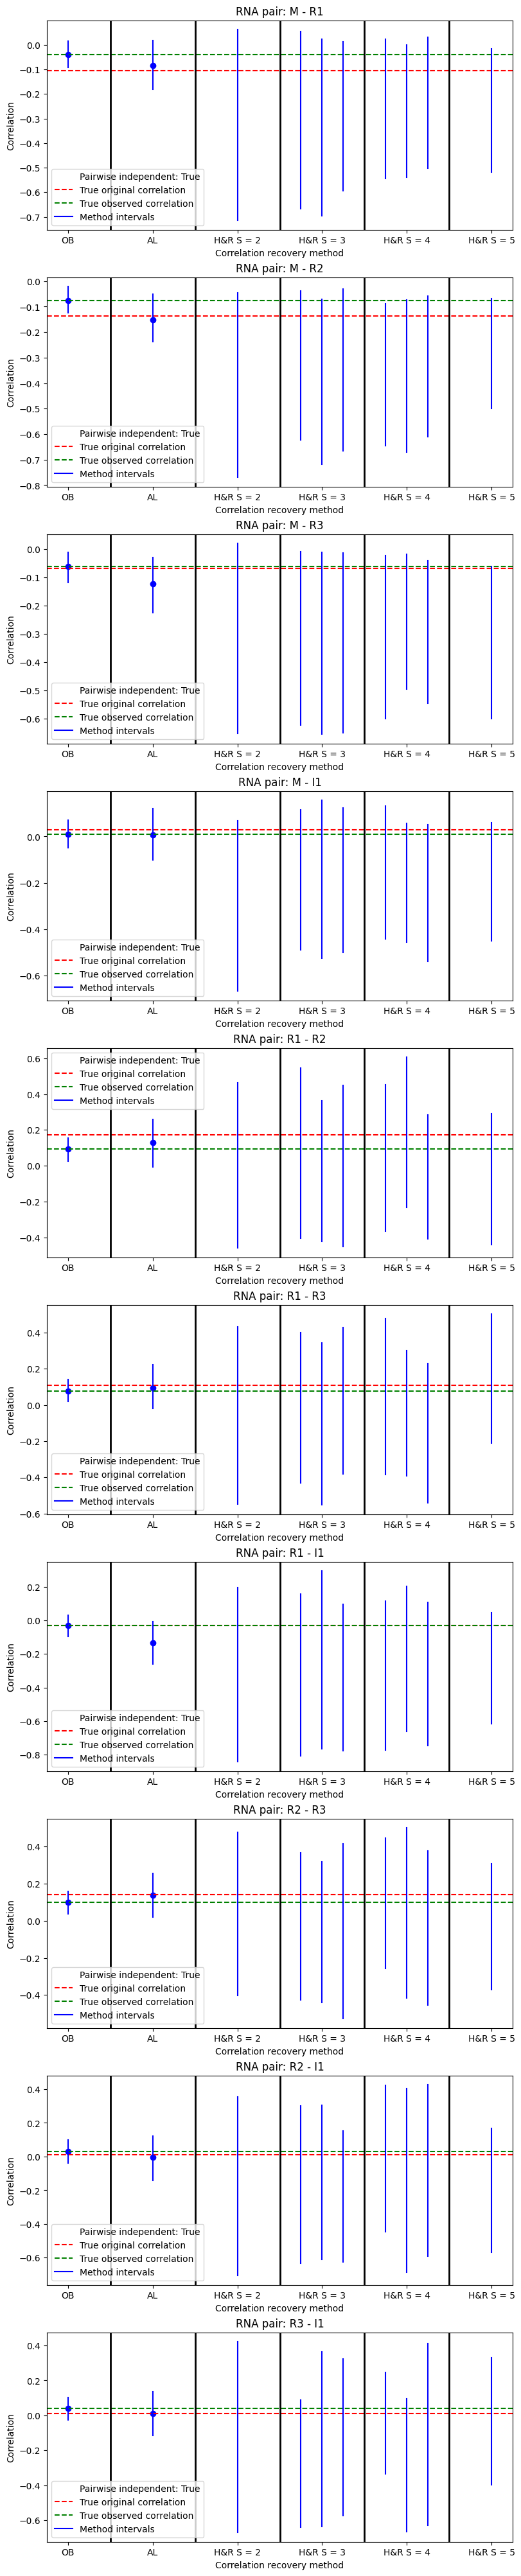

In [329]:
M = D * (D - 1) // 2

fig, axs = plt.subplots(M, 1, squeeze=False, figsize=(8, 4 * M), constrained_layout=True)

m = 0
for i in range(D):
    for j in range(i + 1, D):

        # independence test
        axs[m, 0].plot([], [], label=f"Pairwise independent: {results[i, j]['independent']}", color="white")

        # true correlations
        axs[m, 0].axhline(correlation_matrix_original[i, j], linestyle="--", color="red", label="True original correlation")
        axs[m, 0].axhline(correlation_matrix_observed[i, j], linestyle="--", color="green", label="True observed correlation")

        #OB
        axs[m, 0].plot([0.5]*2, results[i, j]['OB'][1:], color="blue", label="Method intervals")
        axs[m, 0].scatter([0.5], results[i, j]['OB'][0], color="blue")

        # AL
        axs[m, 0].plot([1.5]*2, results[i, j]['AL'][1:], color="blue")
        axs[m, 0].scatter([1.5], results[i, j]['AL'][0], color="blue")

        # H&R intervals
        for S in range(2, D + 1):
            intervals = results[i, j][S]
            K = len(intervals) + 1
            for k, interval in enumerate(intervals):
                axs[m, 0].plot([S + ((k + 1) / K)]*2, interval[1:], color="blue")
                #axs[m, 0].scatter([S + ((k + 1) / K)], interval[0], color="blue")

        # dividers
        for k in range(1, D + 1):
            axs[m, 0].axvline(k, color="black", lw=2)

        # labels
        axs[m, 0].set_ylabel("Correlation")
        axs[m, 0].set_xticks([k + 0.5 for k in range(D + 1)])
        axs[m, 0].set_xticklabels(["OB", "AL"] + [f"H&R S = {S}" for S in range(2, D + 1)])
        axs[m, 0].set_xlabel("Correlation recovery method")
        axs[m, 0].legend()

        # title
        axs[m, 0].set_title(f"RNA pair: {RNA_labels[i]} - {RNA_labels[j]}")

        m += 1

### Coverage statistics

In [330]:
coverage_list = []
for S in range(2, D + 1):
    coverage = []
    for i in range(D):
        for j in range(i + 1, D):
            for interval in results[i, j][S]:
                if interval[1] <= correlation_matrix_original[i, j] and interval[2] >= correlation_matrix_original[i, j]:
                    coverage.append(1)
                else:
                    coverage.append(0)                  
    coverage_list.append(float(np.mean(coverage)))

In [331]:
coverage_list

[1.0, 1.0, 1.0, 1.0]

### Width statistics

In [332]:
widths_list = []
for S in range(2, D + 1):
    widths = []
    for i in range(D):
        for j in range(i + 1, D):
            for interval in results[i, j][S]:
                widths.append(interval[2] - interval[1])
    widths_list.append(widths)

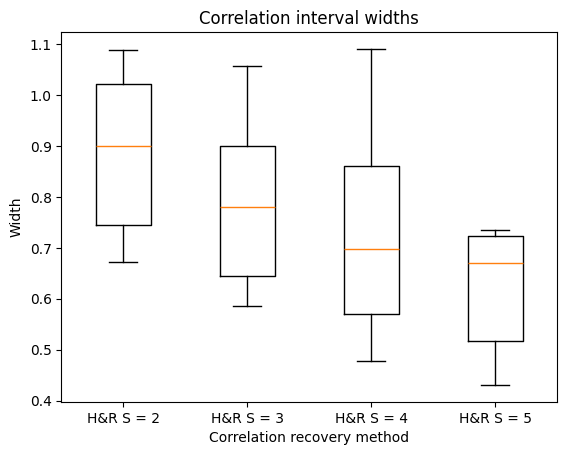

In [333]:
fig, axs = plt.subplots()
axs.boxplot(widths_list);
axs.set_xticklabels([f"H&R S = {S}" for S in range(2, D + 1)])
axs.set_ylabel("Width")
axs.set_xlabel("Correlation recovery method")
axs.set_title("Correlation interval widths")
plt.show()

# (3) Real data: miRNA - {mRNA targets}

## Load data

In [339]:
# load pcRNA
adata_pcRNA = ad.read_h5ad("TotalX_HEK293T_pcRNA.h5ad")

# load miRNA
adata_miRNA = ad.read_h5ad("TotalX_HEK293T_miRNA.h5ad")

# load capture
beta = np.loadtxt("TotalX_HEK293T_capture.txt")

In [340]:
# load results
ind_MF_df = pd.read_csv("Results/New/independent_MF.csv", index_col=0)
int_MF_df = pd.read_csv("Results/New/interacting_MF.csv", index_col=0)
corr_df = pd.read_csv("Results/New/correlation.csv", index_col=0)

## Select miRNA & mRNA targets

In [361]:
# choose miRNA
miRNA = "MIR3658" # "MIR4709" # "MIR3655"

# select results
ind = ind_MF_df[f'{miRNA}_status']
mid = int_MF_df[f'{miRNA}_HAR_mid']

In [362]:
# size
M = 5

# get names of negatively correlated interacting pcRNA
names_neg = mid[mid < -0.25].index.tolist()
names_neg = rng.choice(names_neg, size=M, replace=False)

# subset adata
adata_neg = adata_pcRNA[:, adata_pcRNA.var['GeneName'].isin(names_neg)]

print(names_neg)

['SOX5' 'SIPA1L1' 'LGR4' 'DHRSX' 'OVOL2']


In [363]:
# concatenate miRNA & mRNA adata
adata_selection = ad.concat([
    adata_miRNA[:, adata_miRNA.var['GeneName'] == miRNA],
    adata_neg],
    axis=1
)
adata_selection

AnnData object with n_obs × n_vars = 11945 × 6
    var: 'gene_ids', 'feature_types', 'genome', 'GeneName', 'gene_id', 'biotype'

## Optimize

In [364]:
# construct dataset
data_SDP = SDP_miRNA.dataset.Dataset()

# duplicate full data (miRNA + mRNA) for easy indexing
data_SDP.construct_dataset_adata(
    adata_selection,
    adata_selection,
    beta
)

# total species
D = adata_selection.n_vars

# optimization sizes
Smin = 2
Smax = 3

In [365]:
# store results
results = np.empty((D, D), dtype=object)
for i in range(D):
    for j in range(i + 1, D):
        results[i, j] = {S: [] for S in range(Smin, Smax + 1)}

In [366]:
# settings
d = 3
N = 1000

# for each number of species
for S in range(Smin, Smax + 1):

    # get all unique species selections
    combs = list(combinations(range(D), r=S))

    # construct gene queries (index all from sparse_A)
    gene_queries = [
        [list(idxs), []] for idxs in combs
    ]

    # update dataset
    data_SDP.gene_queries = gene_queries
    data_SDP.total_gene_queries = len(gene_queries)

    # bootstrap
    data_SDP.bootstrap(d=d)

    # Model Free Interacting test
    MF_int = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(data_SDP, d=d, N=N)
    MF_int.analyse_dataset()

    # compute pairwise correlations from H&R samples
    for sx in range(S):
        for sy in range(sx + 1, S):
            _, HAR_interval = MF_int.compute_dataset_correlation(Sx=sx, Sy=sy)
            HAR_midpoint = (HAR_interval[:, 0] + HAR_interval[:, 1]) / 2

            # store point & intervals
            for i, query in enumerate(gene_queries):
                results[query[0][sx], query[0][sy]][S].append(np.array([HAR_midpoint[i], HAR_interval[i, 0], HAR_interval[i, 1]]))

100%|██████████| 20/20 [00:00<00:00, 22.00it/s]


In [367]:
# pairwise independence test & analytic correlation

# get indices (need to use sparse_A & sparse_B or else correlation complains)
Is, Js = np.triu_indices(D, k=1)
gene_queries = [
    [[int(i)], [int(j)]] for i, j in zip(Is, Js)
]

# update dataset
data_SDP.gene_queries = gene_queries
data_SDP.total_gene_queries = len(gene_queries)

# bootstrap
data_SDP.bootstrap(d=d)

# Model Free Independence test
MF_ind = SDP_miRNA.optimization.ModelFreeOptimization(data_SDP, d=d)
MF_ind.analyse_dataset()

# store status
for i, query in enumerate(gene_queries):
    status = (MF_ind.result_dict[i]['status'] == "OPTIMAL")
    results[query[0][0], query[1][0]]['independent'] = status

# analytic correlation
OB, AL = SDP_miRNA.correlation.compute_correlations(data_SDP)

# store point & intervals
for i, query in enumerate(gene_queries):
    results[query[0][0], query[1][0]]['OB'] = OB[i, :]
    results[query[0][0], query[1][0]]['AL'] = AL[i, :]

100%|██████████| 1/1 [00:00<00:00,  2.51it/s]


## Display

### Single pair

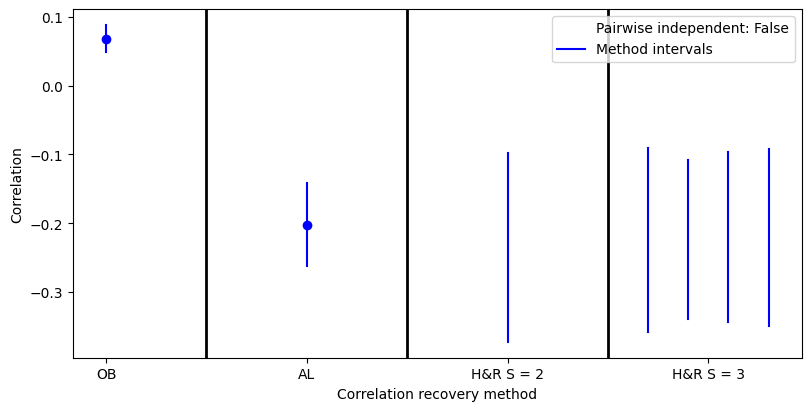

In [368]:
i, j = 0, 1

fig, axs = plt.subplots(1, 1, squeeze=False, figsize=(8, 4), constrained_layout=True)

# independence test
axs[0, 0].plot([], [], label=f"Pairwise independent: {results[i, j]['independent']}", color="white")

# true correlations
#axs[0, 0].axhline(correlation_matrix_original[i, j], linestyle="--", color="red", label="True original correlation")
#axs[0, 0].axhline(correlation_matrix_observed[i, j], linestyle="--", color="green", label="True observed correlation")

#OB
axs[0, 0].plot([0.5]*2, results[i, j]['OB'][1:], color="blue", label="Method intervals")
axs[0, 0].scatter([0.5], results[i, j]['OB'][0], color="blue")

# AL
axs[0, 0].plot([1.5]*2, results[i, j]['AL'][1:], color="blue")
axs[0, 0].scatter([1.5], results[i, j]['AL'][0], color="blue")

# H&R intervals
for S in range(Smin, Smax + 1):
    intervals = results[i, j][S]
    K = len(intervals) + 1
    for k, interval in enumerate(intervals):
        axs[0, 0].plot([S + ((k + 1) / K)]*2, interval[1:], color="blue")
        #axs[0, 0].scatter([S + ((k + 1) / K)], interval[0], color="blue")

# dividers
for k in range(1, Smax + 1):
    axs[0, 0].axvline(k, color="black", lw=2)

# labels
axs[0, 0].set_ylabel("Correlation")
axs[0, 0].set_xticks([k + 0.5 for k in range(Smax + 1)])
axs[0, 0].set_xticklabels(["OB", "AL"] + [f"H&R S = {S}" for S in range(Smin, Smax + 1)])
axs[0, 0].set_xlabel("Correlation recovery method")
axs[0, 0].legend()

### Stacked plot

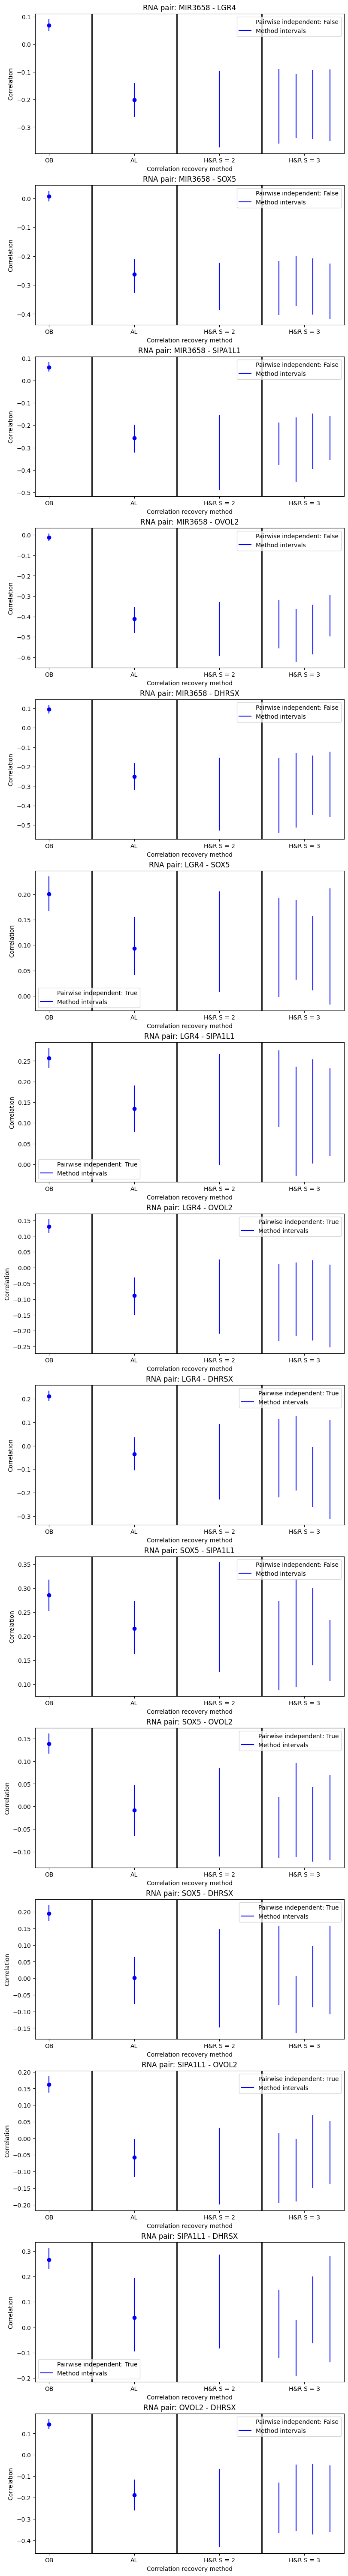

In [379]:
M = D * (D - 1) // 2
RNA_labels = adata_selection.var['GeneName'].values

fig, axs = plt.subplots(M, 1, squeeze=False, figsize=(8, 4 * M), constrained_layout=True)

m = 0
for i in range(D):
    for j in range(i + 1, D):

        # independence test
        axs[m, 0].plot([], [], label=f"Pairwise independent: {results[i, j]['independent']}", color="white")

        # true correlations
        #axs[m, 0].axhline(correlation_matrix_original[i, j], linestyle="--", color="red", label="True original correlation")
        #axs[m, 0].axhline(correlation_matrix_observed[i, j], linestyle="--", color="green", label="True observed correlation")

        #OB
        axs[m, 0].plot([0.5]*2, results[i, j]['OB'][1:], color="blue", label="Method intervals")
        axs[m, 0].scatter([0.5], results[i, j]['OB'][0], color="blue")

        # AL
        axs[m, 0].plot([1.5]*2, results[i, j]['AL'][1:], color="blue")
        axs[m, 0].scatter([1.5], results[i, j]['AL'][0], color="blue")

        # H&R intervals
        for S in range(Smin, Smax + 1):
            intervals = results[i, j][S]
            K = len(intervals) + 1
            for k, interval in enumerate(intervals):
                axs[m, 0].plot([S + ((k + 1) / K)]*2, interval[1:], color="blue")
                #axs[m, 0].scatter([S + ((k + 1) / K)], interval[0], color="blue")

        # dividers
        for k in range(1, Smax + 1):
            axs[m, 0].axvline(k, color="black", lw=2)

        # labels
        axs[m, 0].set_ylabel("Correlation")
        axs[m, 0].set_xticks([k + 0.5 for k in range(Smax + 1)])
        axs[m, 0].set_xticklabels(["OB", "AL"] + [f"H&R S = {S}" for S in range(Smin, Smax + 1)])
        axs[m, 0].set_xlabel("Correlation recovery method")
        axs[m, 0].legend()

        # title
        axs[m, 0].set_title(f"RNA pair: {RNA_labels[i]} - {RNA_labels[j]}")

        m += 1

### Width statistics

In [380]:
widths_list = []
for S in range(Smin, Smax + 1):
    widths = []
    for i in range(D):
        for j in range(i + 1, D):
            for interval in results[i, j][S]:
                widths.append(interval[2] - interval[1])
    widths_list.append(widths)

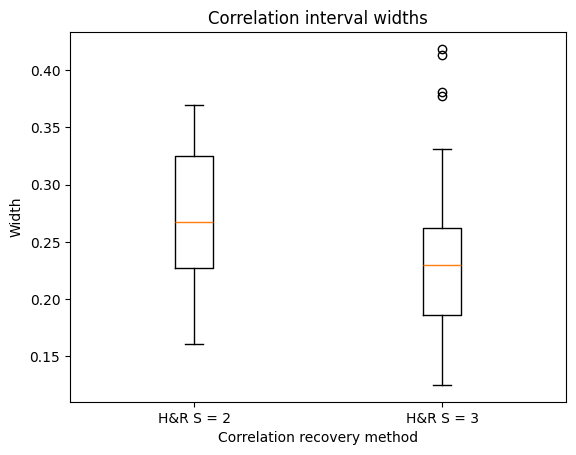

In [381]:
fig, axs = plt.subplots()
axs.boxplot(widths_list);
axs.set_xticklabels([f"H&R S = {S}" for S in range(Smin, Smax + 1)])
axs.set_ylabel("Width")
axs.set_xlabel("Correlation recovery method")
axs.set_title("Correlation interval widths")
plt.show()